# Predicting New-User Engagement on Zindi
### Will a user who just signed up still be active in their second month?

Data: [Zindi New User Engagement Prediction Challenge](https://zindi.africa/competitions/zindi-new-user-engagement-prediction-challenge) (Zindi, 2022–23)

**Outline**

1. Problem & data (load, build target, X / y)
2. Data preparation: encoding, missing values, feature engineering
3. Exploratory analysis with Seaborn → what it changes in the ML setup
4. Validation design & metric
5. Models, hyper-parameter search, results
6. Findings, real-world impact, conclusions

## 1. The problem

**Zindi** is Africa's largest data-science competition platform ($\approx$ 12 k new sign-ups in the 7 months of this dataset).
Most sign-ups are *one-month tourists*: in our data only **12–21 %** of a typical monthly cohort comes back in its second month.

**Task.** For every user who registered in month *m*, predict whether they will do **anything** on Zindi
(view a page, join a competition, submit, post…) in month *m + 1*. → binary classification.

**Why it matters**

- Acquisition is expensive; a user who survives month 2 is far more likely to become a long-term community member, competitor and potential hire for Zindi's clients.
- Churn happens fast. Zindi needs to know **at the end of the first month** who is about to drop out, while there is still time to act.

**How the model helps**

- *Targeted retention*: send onboarding nudges / beginner competitions / mentorship to users with low predicted probability instead of spamming everybody → lower cost, less unsubscribe fatigue.
- *Prioritisation*: identify likely-engaged newcomers for community programmes and hackathon invitations.
- *Product insight*: which first-month behaviours drive retention (e.g. submitting vs. only browsing)?

## 1.1 Loading the data with pandas

Eight relational tables, linked by `User_ID` / `Competition ID`. Dates are **masked**: year and month are recoded
("*months are in chronological order but January is not necessarily month 1*"), time of day and day-of-month are kept.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import logging; logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)   # quiet font fallback messages
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.ticker import PercentFormatter, ScalarFormatter, NullFormatter
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (f1_score, precision_score, recall_score, average_precision_score,
                             roc_auc_score, precision_recall_curve, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.inspection import permutation_importance
from sklearn.base import clone

# Figure style: high resolution (retina x 150 dpi), Times New Roman, light grid, no top/right frame
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'figure.constrained_layout.use': True,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'Liberation Serif', 'Nimbus Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 12, 'axes.titlesize': 13.5, 'axes.titleweight': 'normal', 'axes.titlepad': 10,
    'axes.labelsize': 12.5, 'xtick.labelsize': 11.5, 'ytick.labelsize': 11.5,
    'legend.fontsize': 11, 'legend.frameon': False,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': '#4D4D4D', 'axes.linewidth': 0.9,
    'grid.color': '#E4E4E4', 'grid.linewidth': 0.8,
})
BLUE, RED, GREY, GREEN, ORANGE = '#3A6EA5', '#C0504D', '#B4B4B4', '#4E9A6B', '#D98C3F'
pd.set_option('display.width', 160, 'display.max_columns', 30, 'display.max_colwidth', 120)
RNG = 42

In [2]:
D = '../data/'                                         # raw Zindi tables (shared by both versions)
users = pd.read_csv(D + 'Users.csv')
act   = pd.read_csv(D + 'UserActivity.csv')            # page views / clicks
part  = pd.read_csv(D + 'CompetitionPartipation.csv')  # competition enrolments
disc  = pd.read_csv(D + 'Discussion.csv')
com   = pd.read_csv(D + 'Comments.csv')
comps = pd.read_csv(D + 'Competition.csv')
sample_sub = pd.read_csv(D + 'SampleSubmission.csv')

pd.DataFrame({n: [len(t), t.shape[1]] for n, t in
              dict(Users=users, UserActivity=act, CompetitionParticipation=part,
                   Discussion=disc, Comments=com, Competition=comps).items()},
             index=['rows', 'cols']).T

,rows,cols
Users,12413,8
UserActivity,317292,6
CompetitionParticipation,8385,8
Discussion,1439,9
Comments,467,6
Competition,247,20


In [3]:
users.head(3).T          # transposed: one column per user

,0,1,2
FeatureX,0,1,0
FeatureY,0,0,0
User_ID,ID_DC6S4E9O,ID_E8S97OUT,ID_QZ1HASL3
Countries_ID,X9GR,X9GR,X9GR
Created At time,19:33:13.663391,22:18:18.228921,23:13:03.266635
Created At Year,1,1,1
Created At Month,1,12,1
Created At Day_of_month,16,27,1


In [4]:
act.head(3).T

,0,1,2
User_ID,ID_RT43AK77,ID_RT43AK77,ID_RT43AK77
Title,comp_ID_IV5D,comp_ID_IV5D,comp_ID_IV5D
datetime time,22:00:38,00:41:02,00:53:15
datetime Year,1,1,1
datetime Month,11,11,11
datetime Day_of_month,22,23,23


## 1.2 Recovering the time axis

All users are in masked *Year 1*, with masked months {11, 12, 1, 2, 3, 4, 5}. In what order?
We cross-tabulate **sign-up month** (rows) vs **activity month** (columns): users can only be active *after* they register,
so the zero pattern reveals the chronology.

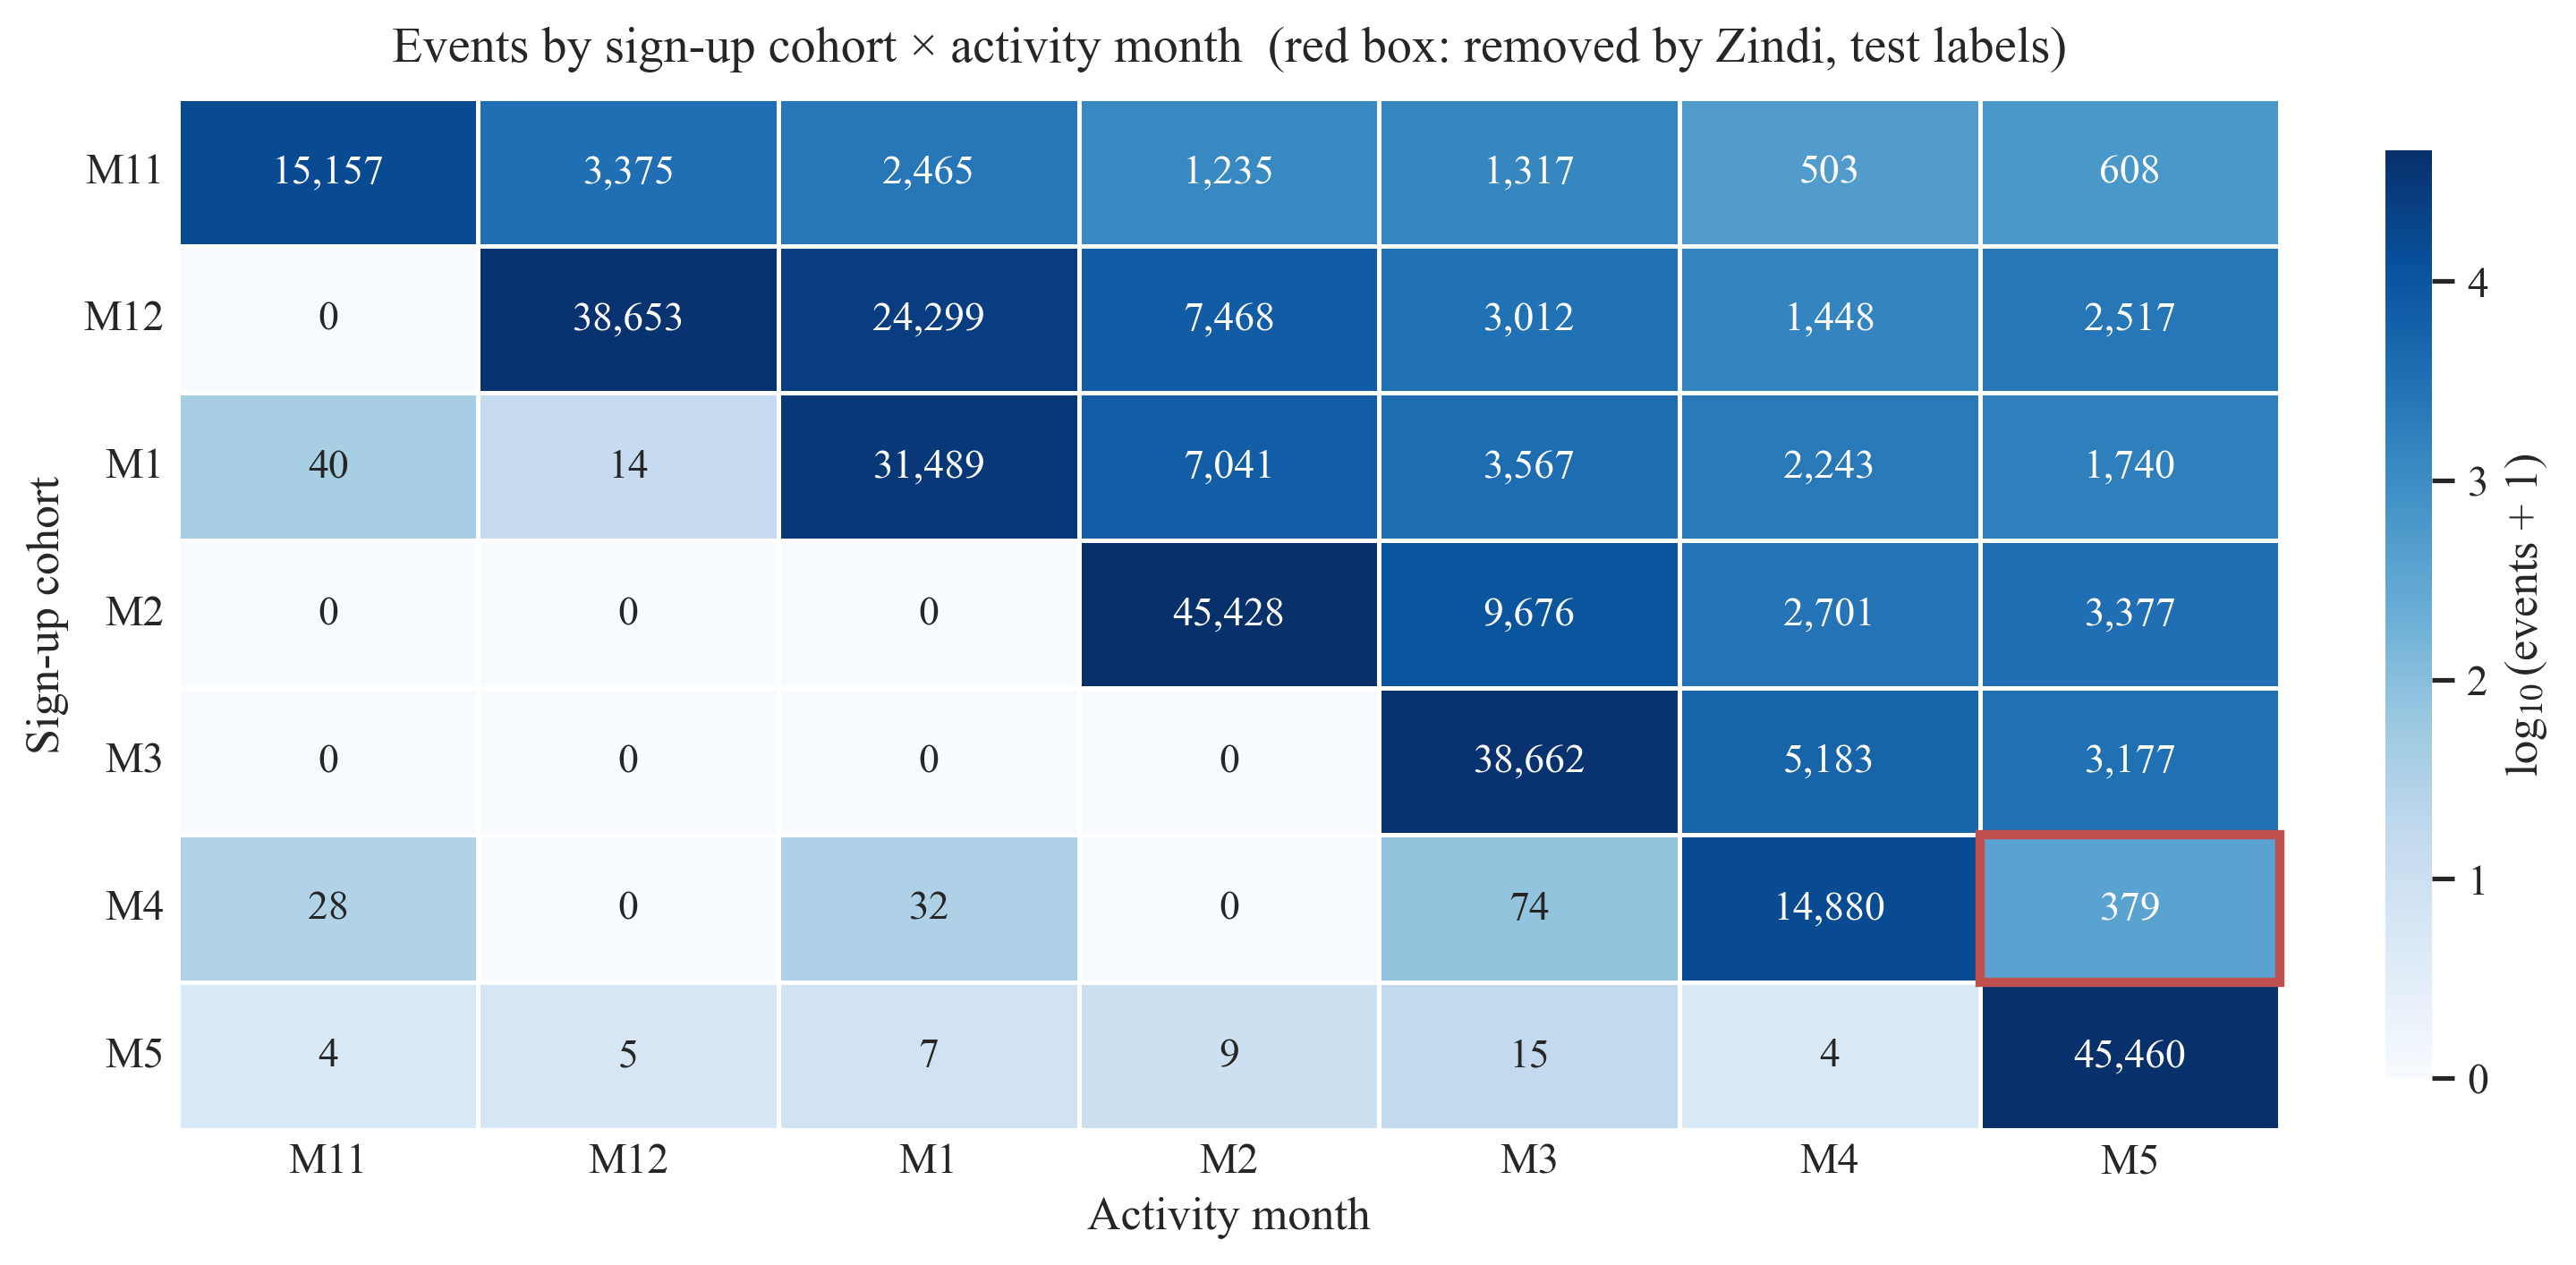

In [5]:
ORDER = {11: 0, 12: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6}           # masked month -> chronological index t
LABEL = {v: f'M{k}' for k, v in ORDER.items()}                    # t -> display label

def standardise(df, prefix):
    df = df.rename(columns={f'{prefix} Month': 'month', f'{prefix} Day_of_month': 'day', f'{prefix} time': 'time'})
    df['t'] = df['month'].map(ORDER)
    return df

users = standardise(users, 'Created At').rename(columns={'t': 'cohort', 'day': 'signup_day'})
act, part = standardise(act, 'datetime'), standardise(part, 'Created At')
disc, com = standardise(disc, 'Created At'), standardise(com, 'Created At')

am = act.merge(users[['User_ID', 'cohort']], on='User_ID')
ct = pd.crosstab(am.cohort, am.t.rename('activity month'))
ct = ct.rename(index=LABEL, columns=LABEL)
fig, ax = plt.subplots(figsize=(9.5, 4.6))
sns.heatmap(np.log10(ct + 1), annot=ct.apply(lambda col: col.map('{:,}'.format)), fmt='', cmap='Blues',
            linewidths=0.8, linecolor='white', annot_kws={'size': 11},
            cbar_kws={'label': r'$\log_{10}$(events + 1)', 'shrink': 0.9}, ax=ax)
r_test, c_test = list(ct.index).index('M4'), list(ct.columns).index('M5')     # month-2 activity of the test cohort
ax.add_patch(plt.Rectangle((c_test, r_test), 1, 1, fill=False, edgecolor=RED, lw=2.5, clip_on=False))
ax.set(xlabel='Activity month', ylabel='Sign-up cohort',
       title='Events by sign-up cohort × activity month  (red box: removed by Zindi, test labels)')
ax.tick_params(axis='both', length=0); ax.tick_params(axis='y', rotation=0); ax.grid(False)
plt.show()

**Reading the matrix**

- (Almost) upper-triangular — only a few dozen stray events below the diagonal $\Rightarrow$ chronological order is **M11 → M12 → M1 → M2 → M3 → M4 → M5** (7 consecutive months).
- The **M4 cohort has essentially no M5 activity** (8 users out of 1 382): Zindi removed it — the M4 cohort is the
  hidden **test set** (`SampleSubmission` = 1 340 M4 users, "`_Month_5`").
- $\Rightarrow$ We must **build the training labels ourselves** from cohorts M11 … M3 (their month-*m+1* is observed).

## 1.3 Target definition and X / y split

`Active = 1` if the user has **any** record (activity log, competition enrolment, discussion or comment) in the month
right after the sign-up month. Features may only use information from the **sign-up month** (what Zindi knows
at the moment it has to act) — anything later would leak the target.

In [6]:
events = pd.concat([x[['User_ID', 't']] for x in (act, part, disc, com)])
ev = events.merge(users[['User_ID', 'cohort']], on='User_ID')
active_next = set(ev.loc[ev.t == ev.cohort + 1, 'User_ID'])
users['Active'] = users.User_ID.isin(active_next).astype(int)

LABELLED = [0, 1, 2, 3, 4]      # M11..M3 cohorts: label observed
TEST_COHORT = 5                 # M4 cohort: label hidden by Zindi
summary = users[users.cohort <= TEST_COHORT].groupby('cohort').agg(users=('Active', 'size'), active_rate=('Active', 'mean'))
summary.index = summary.index.map(LABEL); summary.loc['M4', 'active_rate'] = np.nan
summary.T.round(3)

cohort,M11,M12,M1,M2,M3,M4
users,1262.000,1982.000,1504.000,2278.000,2000.000,1382.0
active_rate,0.198,0.784,0.207,0.175,0.122,NaN


## 2. Data preparation

| Issue | What we do | Why |
|---|---|---|
| Events are in long, multi-table logs | aggregate per user **within the sign-up month only** | one row per user; no look-ahead leakage |
| 70+ raw event titles (`comp_ID_xxx`, `badge_xxx`, …) | group into 18 behaviour families (view competition, submit, download data, …) | IDs are too sparse; the *type* of behaviour is what generalises |
| `Countries_ID` missing for 47 % of users | category `Missing` + binary flag | missingness is informative (see EDA) — imputing a country would be invented data |
| 146 masked countries (high cardinality) | keep top-10, rest → `Other`, **one-hot** | enough users per level; avoids over-fitting rare countries |
| `FeatureY` $\in$ {0, 1, 3} (masked category) | one-hot | codes are nominal, not ordinal |
| `Successful Submission Count` = strings `"count 10"`, NaN | parse number; NaN → 0 | NaN = no successful submission |
| Users with no events in a table | counts → 0 | absence of activity is a true zero |
| Late sign-ups have less time to show activity | `days_observed`, `active_day_ratio`, `days_since_last` | normalises activity by exposure |
| Month lengths are masked too (M2 has 31 days!), M4 log stops at day 22 | window end = last logged day of that month | keeps exposure features consistent between train and test |

In [7]:
def family(title):
    for p in ('comp_', 'blog_', 'job_', 'badge_'):
        if title.startswith(p):
            return 'view_' + p[:-1]
    return title

act['family'] = act.Title.map(family)
act['comp_id'] = np.where(act.Title.str.startswith('comp_'), act.Title.str[5:], None)
FAMILIES = ['view_comp', 'Viewed All Competitions', 'Viewed All Discussions', 'Viewed All Learning Pages',
            'Downloaded Competition Datafile', 'Updated Profile', 'Created Submission', 'view_badge',
            'Confirmed Email', 'Updated Discussion', 'Joined Competition', 'Viewed All Jobs', 'Signed In',
            'Updated Submission', 'view_blog', 'Signed Out', 'view_job', 'Viewed Discussion']

def first_month(df):
    # keep only events that happen in the user's sign-up month
    df = df.merge(users[['User_ID', 'cohort']], on='User_ID')
    return df[df.t == df.cohort]

a0, p0, d0, c0 = map(first_month, (act, part, disc, com))

### Engineered features (all computed from the sign-up month)

- **Volume / regularity**: `n_events`, `n_active_days`, `n_distinct_actions`, `n_distinct_comps`, `active_day_ratio`
- **Recency**: `days_since_last` = days between last activity and month end (fresh activity $\Rightarrow$ likely to continue)
- **Behaviour mix**: counts for 18 event families (submissions, data downloads, learning pages, jobs …)
- **Competition context** (from `CompetitionParticipation` + `Competition`):
  - `n_comps_joined`, `max_sub_bucket` (masked successful-submission bucket)
  - `n_new_comps_joined`: competitions whose **first appearance** in the logs is in the sign-up month — a freshly launched competition is likely still running next month (computed from past/present logs only)
  - `joined_hackathon`: joined a competition that requires a secret code (= hackathon / class event)
- **Community**: `n_discussions`, `n_comments`
- **Profile**: `FeatureX`, `FeatureY`, country, `country_missing`, `signup_day`, `signup_hour`, `days_observed`

In [8]:
counts = pd.crosstab(a0.User_ID, a0.family).reindex(columns=FAMILIES, fill_value=0)
counts.columns = ['n_' + c.lower().replace(' ', '_') for c in counts.columns]
activity = a0.groupby('User_ID').agg(n_events=('family', 'size'), n_active_days=('day', 'nunique'),
                                     n_distinct_actions=('family', 'nunique'), last_active_day=('day', 'max'),
                                     n_distinct_comps=('comp_id', 'nunique'))

first_seen = pd.concat([part[['Competition ID', 't']],
                        act.dropna(subset=['comp_id']).rename(columns={'comp_id': 'Competition ID'})[['Competition ID', 't']]]
                       ).groupby('Competition ID').t.min()
p0 = p0.assign(new_comp=(p0.t == p0['Competition ID'].map(first_seen)).astype(int),
               hackathon=p0['Competition ID'].map(comps.set_index('Comp_ID').SecretCode),
               sub_bucket=p0['Successful Submission Count'].str.extract(r'(\d+)', expand=False).astype(float))
competition = p0.groupby('User_ID').agg(n_comps_joined=('Competition ID', 'nunique'), max_sub_bucket=('sub_bucket', 'max'),
                                        n_new_comps_joined=('new_comp', 'sum'), joined_hackathon=('hackathon', 'max'))

df = (users.set_index('User_ID')
      .join(activity).join(counts).join(competition)
      .assign(n_discussions=d0.User_ID.value_counts(), n_comments=c0.User_ID.value_counts()))
zero_fill = [c for c in df.columns if c.startswith('n_')] + ['max_sub_bucket', 'joined_hackathon']
df[zero_fill] = df[zero_fill].fillna(0)

obs_end = act.groupby('month').day.max()       # last logged day per month (masked lengths; M4 log stops at day 22)
df['days_observed'] = (df.month.map(obs_end) - df.signup_day + 1).clip(lower=1)
df['days_since_last'] = (df.month.map(obs_end) - df.last_active_day).clip(lower=0).fillna(df.days_observed)
df['active_day_ratio'] = df.n_active_days / df.days_observed
df['signup_hour'] = df.time.str[:2].astype(int)
df['country_missing'] = df.Countries_ID.isna().astype(int)
top10 = df.Countries_ID.value_counts().index[:10]
df['country'] = np.select([df.Countries_ID.isin(top10), df.Countries_ID.isna()], [df.Countries_ID, 'Missing'], 'Other')
df = pd.get_dummies(df, columns=['country', 'FeatureY'], prefix=['cty', 'FY'])
df = df.drop(columns=['Countries_ID', 'time', 'Created At Year', 'month', 'last_active_day'])
print('modelling table:', df.shape, '| remaining NaNs:', int(df.isna().sum().sum()))

modelling table: (12413, 52) | remaining NaNs: 0


In [9]:
FEATURES = [c for c in df.columns if c not in ('Active', 'cohort')]
lab = df[df.cohort.isin(LABELLED)]
X, y = lab[FEATURES], lab['Active']                 # <- inputs / output
X_test = df.loc[df.cohort == TEST_COHORT, FEATURES]  # M4 cohort, label hidden
print(f'X: {X.shape}, y: {y.shape}, positive rate = {y.mean():.3f} | X_test: {X_test.shape}')
X[['n_events', 'n_active_days', 'n_comps_joined', 'n_created_submission', 'days_since_last', 'country_missing']].describe().T.round(2)

X: (9026, 50), y: (9026,), positive rate = 0.305 | X_test: (1382, 50)


,count,mean,std,min,25%,50%,75%,max
n_events,9026.0,18.77,25.95,0.0,8.0,12.0,21.0,885.0
n_active_days,9026.0,1.60,1.70,0.0,1.0,1.0,2.0,21.0
n_comps_joined,9026.0,0.56,0.87,0.0,0.0,0.0,1.0,12.0
n_created_submission,9026.0,0.53,3.59,0.0,0.0,0.0,0.0,103.0
days_since_last,9026.0,11.72,9.10,0.0,4.0,10.0,18.0,31.0
country_missing,9026.0,0.39,0.49,0.0,0.0,0.0,1.0,1.0


## 3. Exploratory analysis — 3.1 retention differs strongly by cohort

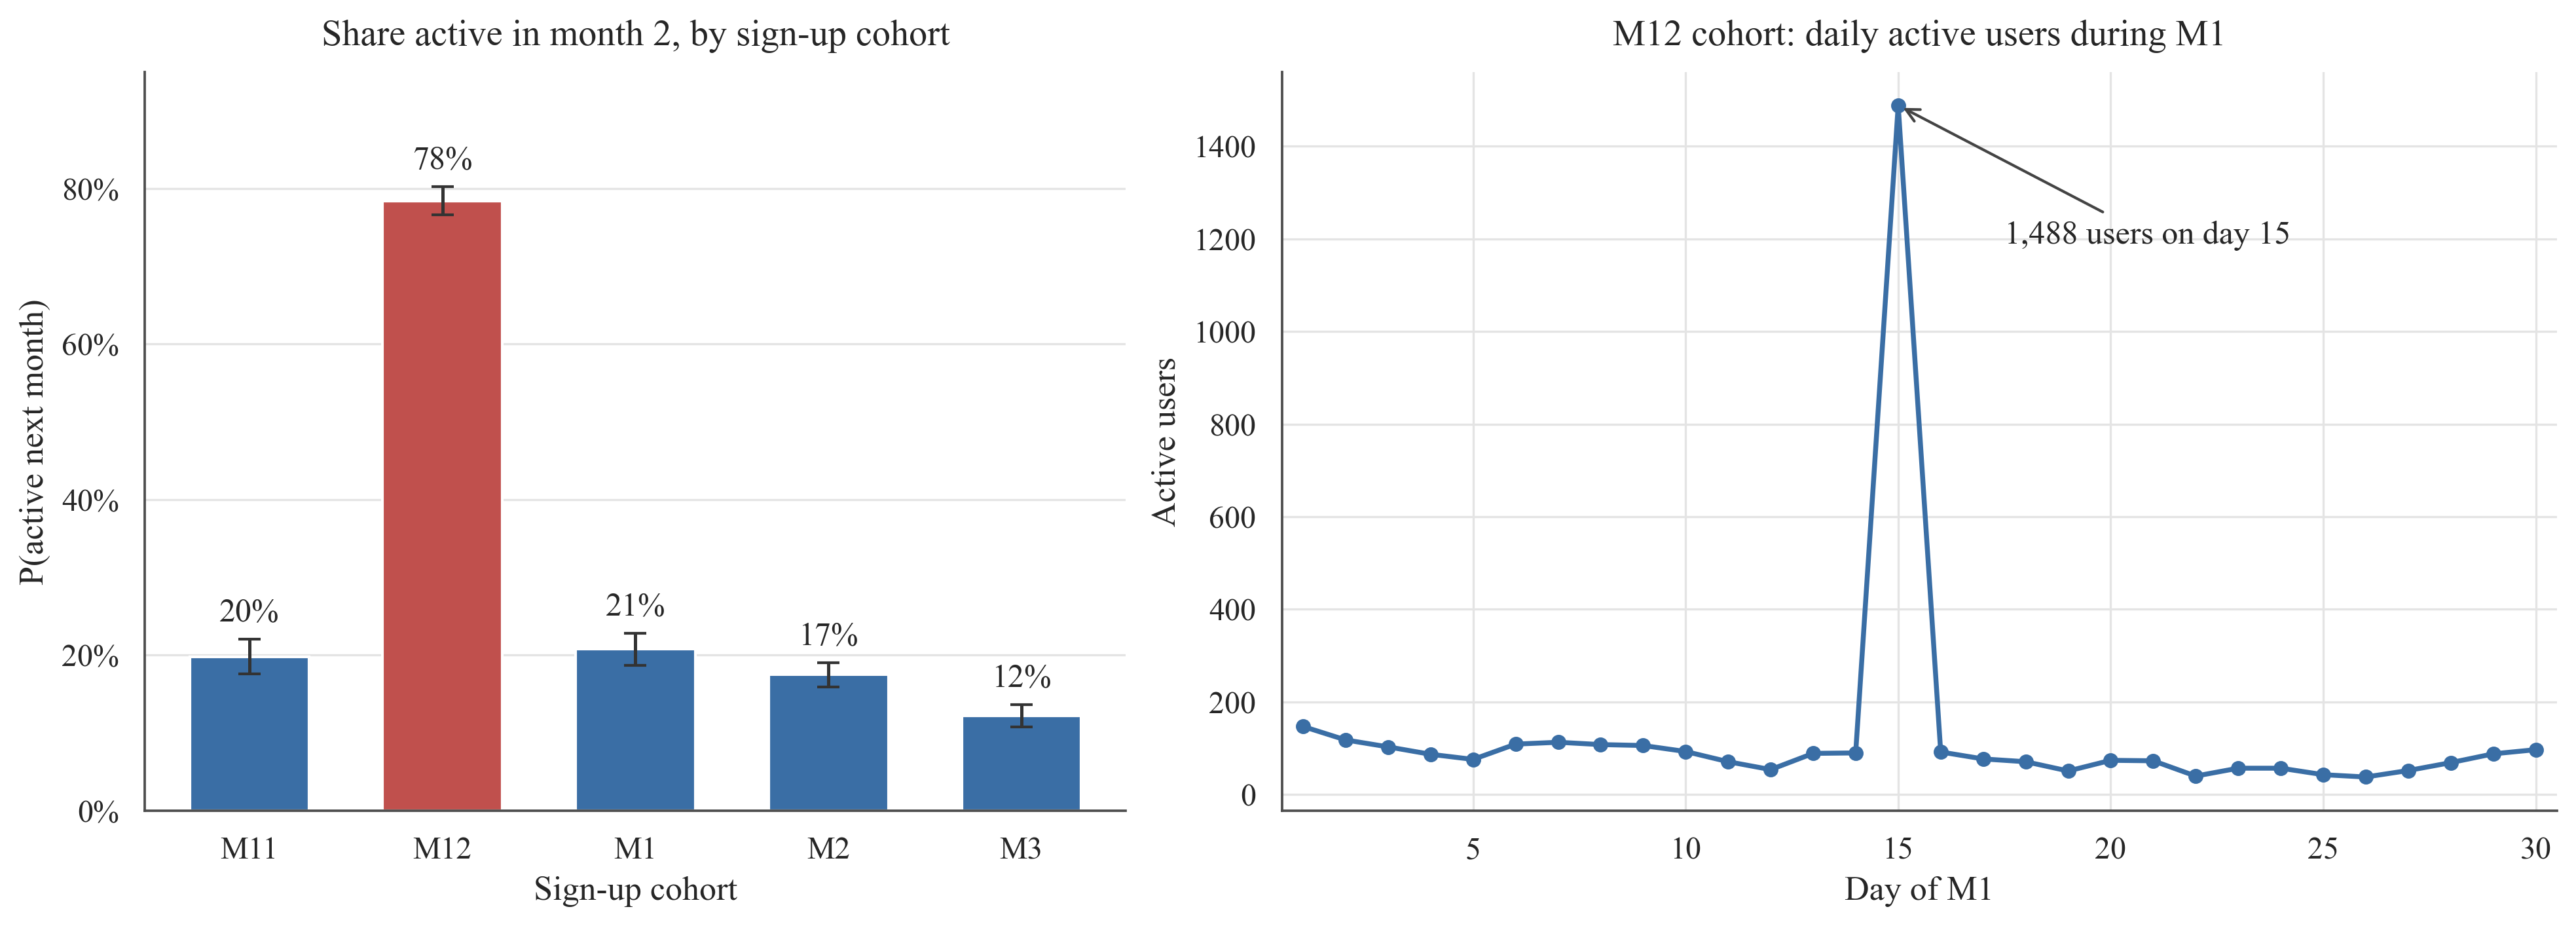

In [10]:
r = lab.assign(cohort=lab.cohort.map(LABEL))
g = r.groupby('cohort').Active
rate = g.mean().reindex([LABEL[t] for t in LABELLED]); n_users = g.size().reindex(rate.index)
ci = 1.96 * np.sqrt(rate * (1 - rate) / n_users)                       # 95 % CI of a proportion

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={'width_ratios': [1, 1.3]})
ax = axes[0]
ax.bar(rate.index, rate.values, yerr=ci.values, capsize=4, width=0.62,
       color=[RED if c == 'M12' else BLUE for c in rate.index], error_kw={'lw': 1.2, 'ecolor': '#333333'})
for x, (v, e) in enumerate(zip(rate.values, ci.values)):
    ax.text(x, v + e + 0.015, f'{v:.0%}', ha='center', va='bottom', fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set_ylim(0, 0.95); ax.grid(axis='x', visible=False)
ax.set(title='Share active in month 2, by sign-up cohort', ylabel='P(active next month)', xlabel='Sign-up cohort')

m12 = act.merge(users[['User_ID', 'cohort']], on='User_ID').query('cohort == 1 and t == 2')
dau = m12.groupby('day').User_ID.nunique()
ax = axes[1]
ax.plot(dau.index, dau.values, marker='o', ms=4.5, lw=1.8, color=BLUE)
pk = dau.idxmax()
ax.annotate(f'{dau[pk]:,} users on day {pk}', xy=(pk, dau[pk]), xytext=(pk + 2.5, dau[pk] * 0.8),
            arrowprops={'arrowstyle': '->', 'color': '#444444', 'lw': 1}, fontsize=12)
ax.set(title='M12 cohort: daily active users during M1', ylabel='Active users', xlabel='Day of M1',
       xlim=(0.5, dau.index.max() + 0.5))
plt.show()

- 4 of 5 cohorts retain **12–21 %**, but the **M12 cohort retains 78 %**.
- M12 users' activity in M1 is one **spike on a single day (about 1 500 users on day 15)**, concentrated on competition
  `ID_528W`: a *secret-code hackathon* hosted in country `X9GR`, running from M12-28 to M2-3.
  M12 sign-ups were mostly **event participants**, whose "retention" was mechanically caused by the event.
- **Consequences for ML**
  1. Label prior is not stationary → a random train/test split would mix cohorts and look over-optimistic → **time-based validation**.
  2. The M12 cohort is not representative of the test cohort → we test **excluding it from training** (Section 4).
  3. Motivated two features: `joined_hackathon`, `n_new_comps_joined`.

## 3.2 First-month engagement vs. month-2 activity

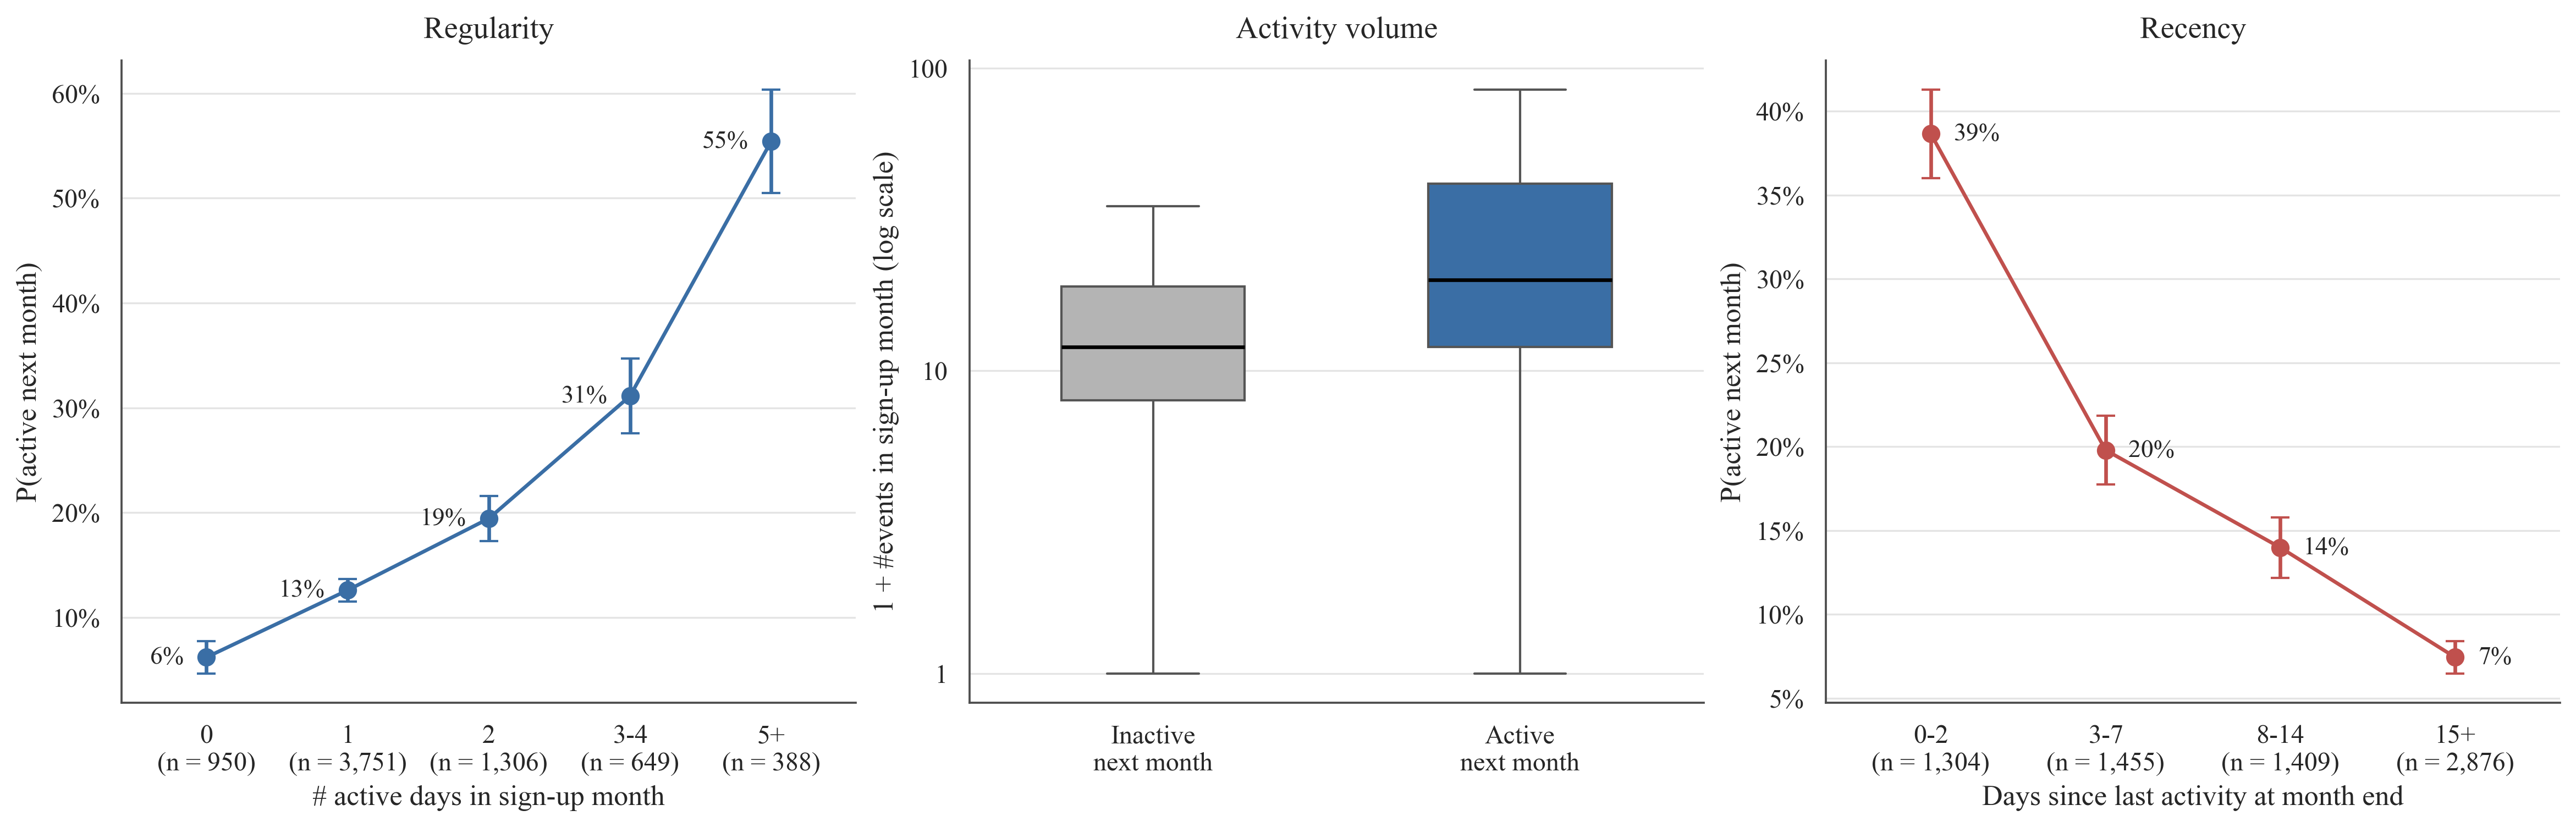

In [11]:
normal = lab[lab.cohort != 1]           # typical cohorts

def rate_panel(ax, groups, y, color, xlabel, title, label_side='right'):
    # P(active next month) per bin with a 95 % CI; the bin size is shown under each tick
    g = y.groupby(groups, observed=True)
    p, n = g.mean(), g.size()
    ci = 1.96 * np.sqrt(p * (1 - p) / n)
    x = np.arange(len(p))
    ax.errorbar(x, p.values, yerr=ci.values, fmt='o-', color=color, ms=7, lw=1.6, capsize=4)
    for xi, v in zip(x, p.values):
        ax.annotate(f'{v:.0%}', (xi, v), textcoords='offset points', xytext=(10 if label_side == 'right' else -10, 0),
                    ha='left' if label_side == 'right' else 'right', va='center', fontsize=11)
    ax.set_xticks(x, [f'{k}\n(n = {m:,})' for k, m in zip(p.index.astype(str), n.values)])
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0)); ax.grid(axis='x', visible=False)
    ax.set(xlabel=xlabel, ylabel='P(active next month)', title=title, xlim=(-0.6, len(p) - 0.4))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.9))
bins = pd.cut(normal.n_active_days, [-1, 0, 1, 2, 4, 31], labels=['0', '1', '2', '3-4', '5+'])
rate_panel(axes[0], bins, normal.Active, BLUE, '# active days in sign-up month', 'Regularity', label_side='left')

box = axes[1].boxplot([1 + normal.loc[normal.Active == k, 'n_events'] for k in (0, 1)], widths=0.5, showfliers=False,
                      patch_artist=True, medianprops={'color': 'black', 'lw': 1.6},
                      whiskerprops={'color': '#555555'}, capprops={'color': '#555555'})
for patch, col in zip(box['boxes'], [GREY, BLUE]):
    patch.set(facecolor=col, edgecolor='#555555')
axes[1].set_yscale('log'); axes[1].yaxis.set_major_formatter(ScalarFormatter()); axes[1].yaxis.set_minor_formatter(NullFormatter())
axes[1].set_xticks([1, 2], ['Inactive\nnext month', 'Active\nnext month']); axes[1].grid(axis='x', visible=False)
axes[1].set(ylabel='1 + #events in sign-up month (log scale)', title='Activity volume')

rec = pd.cut(normal.days_since_last, [-1, 2, 7, 14, 31], labels=['0-2', '3-7', '8-14', '15+'])
rate_panel(axes[2], rec, normal.Active, RED, 'Days since last activity at month end', 'Recency')
plt.show()

- Retention rises monotonically with the **number of active days**: 6 % (no logged activity) → 13 % (1 day) → 55 % (5+ days).
- **Recency** is at least as important as volume: users seen in the last 2 days of the month return 39 % of the time, vs 7 % for users silent for 15+ days.
- Distributions are extremely **right-skewed** (median user: a handful of events) → log-transform counts for the linear model; tree models are invariant.

## 3.3 Behaviour types and profile variables

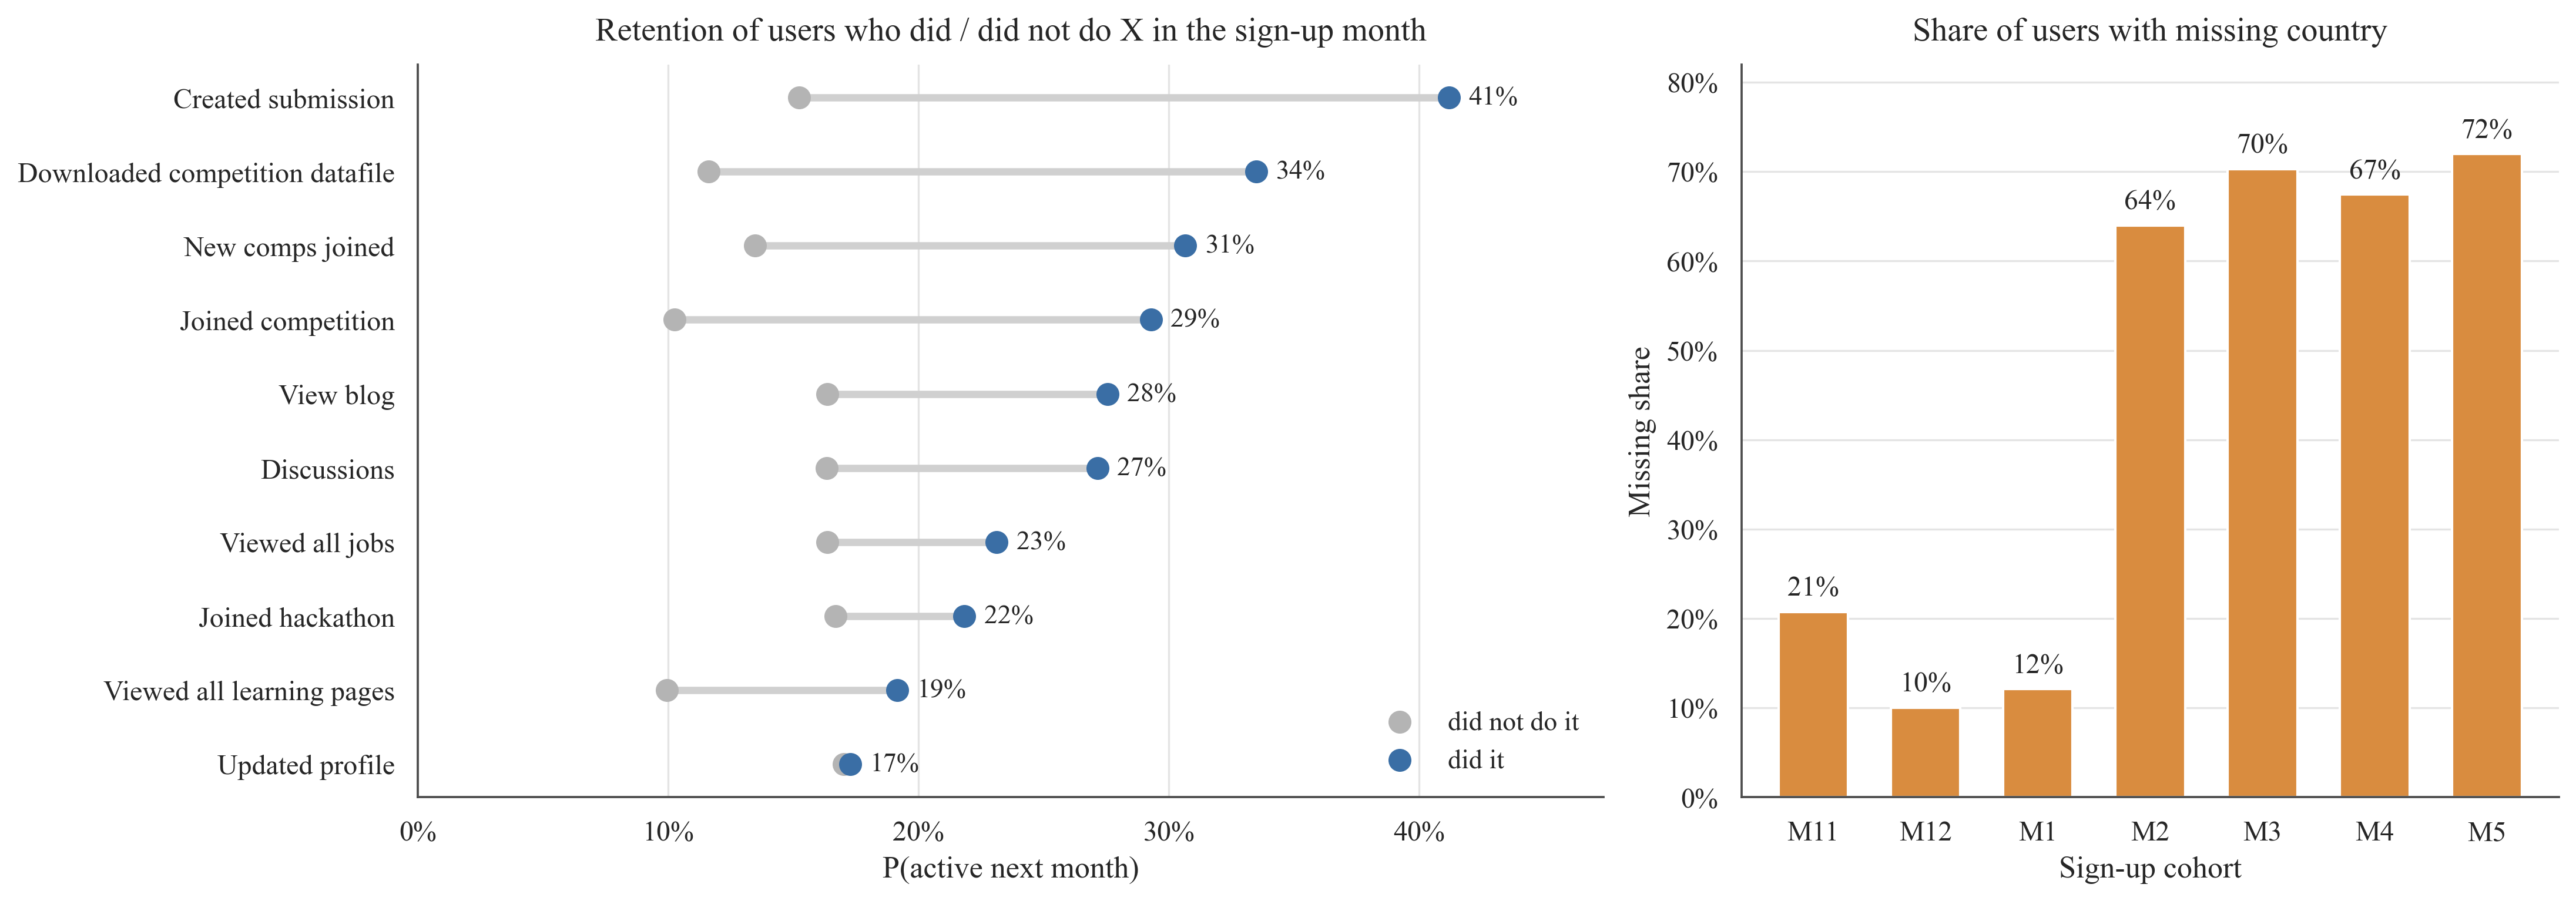

In [12]:
beh = ['n_created_submission', 'n_downloaded_competition_datafile', 'n_joined_competition', 'n_viewed_all_learning_pages',
       'n_viewed_all_jobs', 'n_view_blog', 'n_updated_profile', 'n_discussions', 'joined_hackathon', 'n_new_comps_joined']
rates = pd.DataFrame({b[2:] if b.startswith('n_') else b: normal.groupby(normal[b] > 0).Active.mean() for b in beh}).T
rates.columns = ['did not', 'did']
rates = rates.sort_values('did')

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5), gridspec_kw={'width_ratios': [1.45, 1]})
ax = axes[0]; yy = np.arange(len(rates))
ax.hlines(yy, rates['did not'], rates['did'], color='#D0D0D0', lw=3, zorder=1)
ax.scatter(rates['did not'], yy, color=GREY, s=70, zorder=2, label='did not do it')
ax.scatter(rates['did'], yy, color=BLUE, s=70, zorder=3, label='did it')
for yi, v in zip(yy, rates['did']):
    ax.annotate(f'{v:.0%}', (v, yi), textcoords='offset points', xytext=(8, 0), va='center', fontsize=11)
ax.set_yticks(yy, rates.index.str.replace('_', ' ').str.capitalize())
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0)); ax.set_xlim(0, rates.values.max() * 1.15); ax.grid(axis='y', visible=False)
ax.set(xlabel='P(active next month)', title='Retention of users who did / did not do X in the sign-up month')
ax.legend(loc='lower right')

miss = users[users.cohort <= 6].groupby('cohort').apply(lambda g: g.Countries_ID.isna().mean()).rename(index=LABEL)
ax = axes[1]
ax.bar(miss.index, miss.values, color=ORANGE, width=0.62)
for x, v in enumerate(miss.values):
    ax.text(x, v + 0.012, f'{v:.0%}', ha='center', va='bottom', fontsize=11.5)
ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.set_ylim(0, 0.82); ax.grid(axis='x', visible=False)
ax.set(title='Share of users with missing country', ylabel='Missing share', xlabel='Sign-up cohort')
plt.show()

- *Doing* things (submitting, downloading data, joining competitions, posting) predicts retention much better than
  *reading* (blog, jobs pages). → keep the behaviour-family breakdown instead of a single activity count.
- **Country is missing for 10–21 % of users up to M1 and 64–72 % from M2 on** — a change in the sign-up form, not user behaviour.
  `country_missing` is therefore a *time proxy* that can mislead a model trained on old cohorts → we check whether
  dropping country features helps under temporal validation.

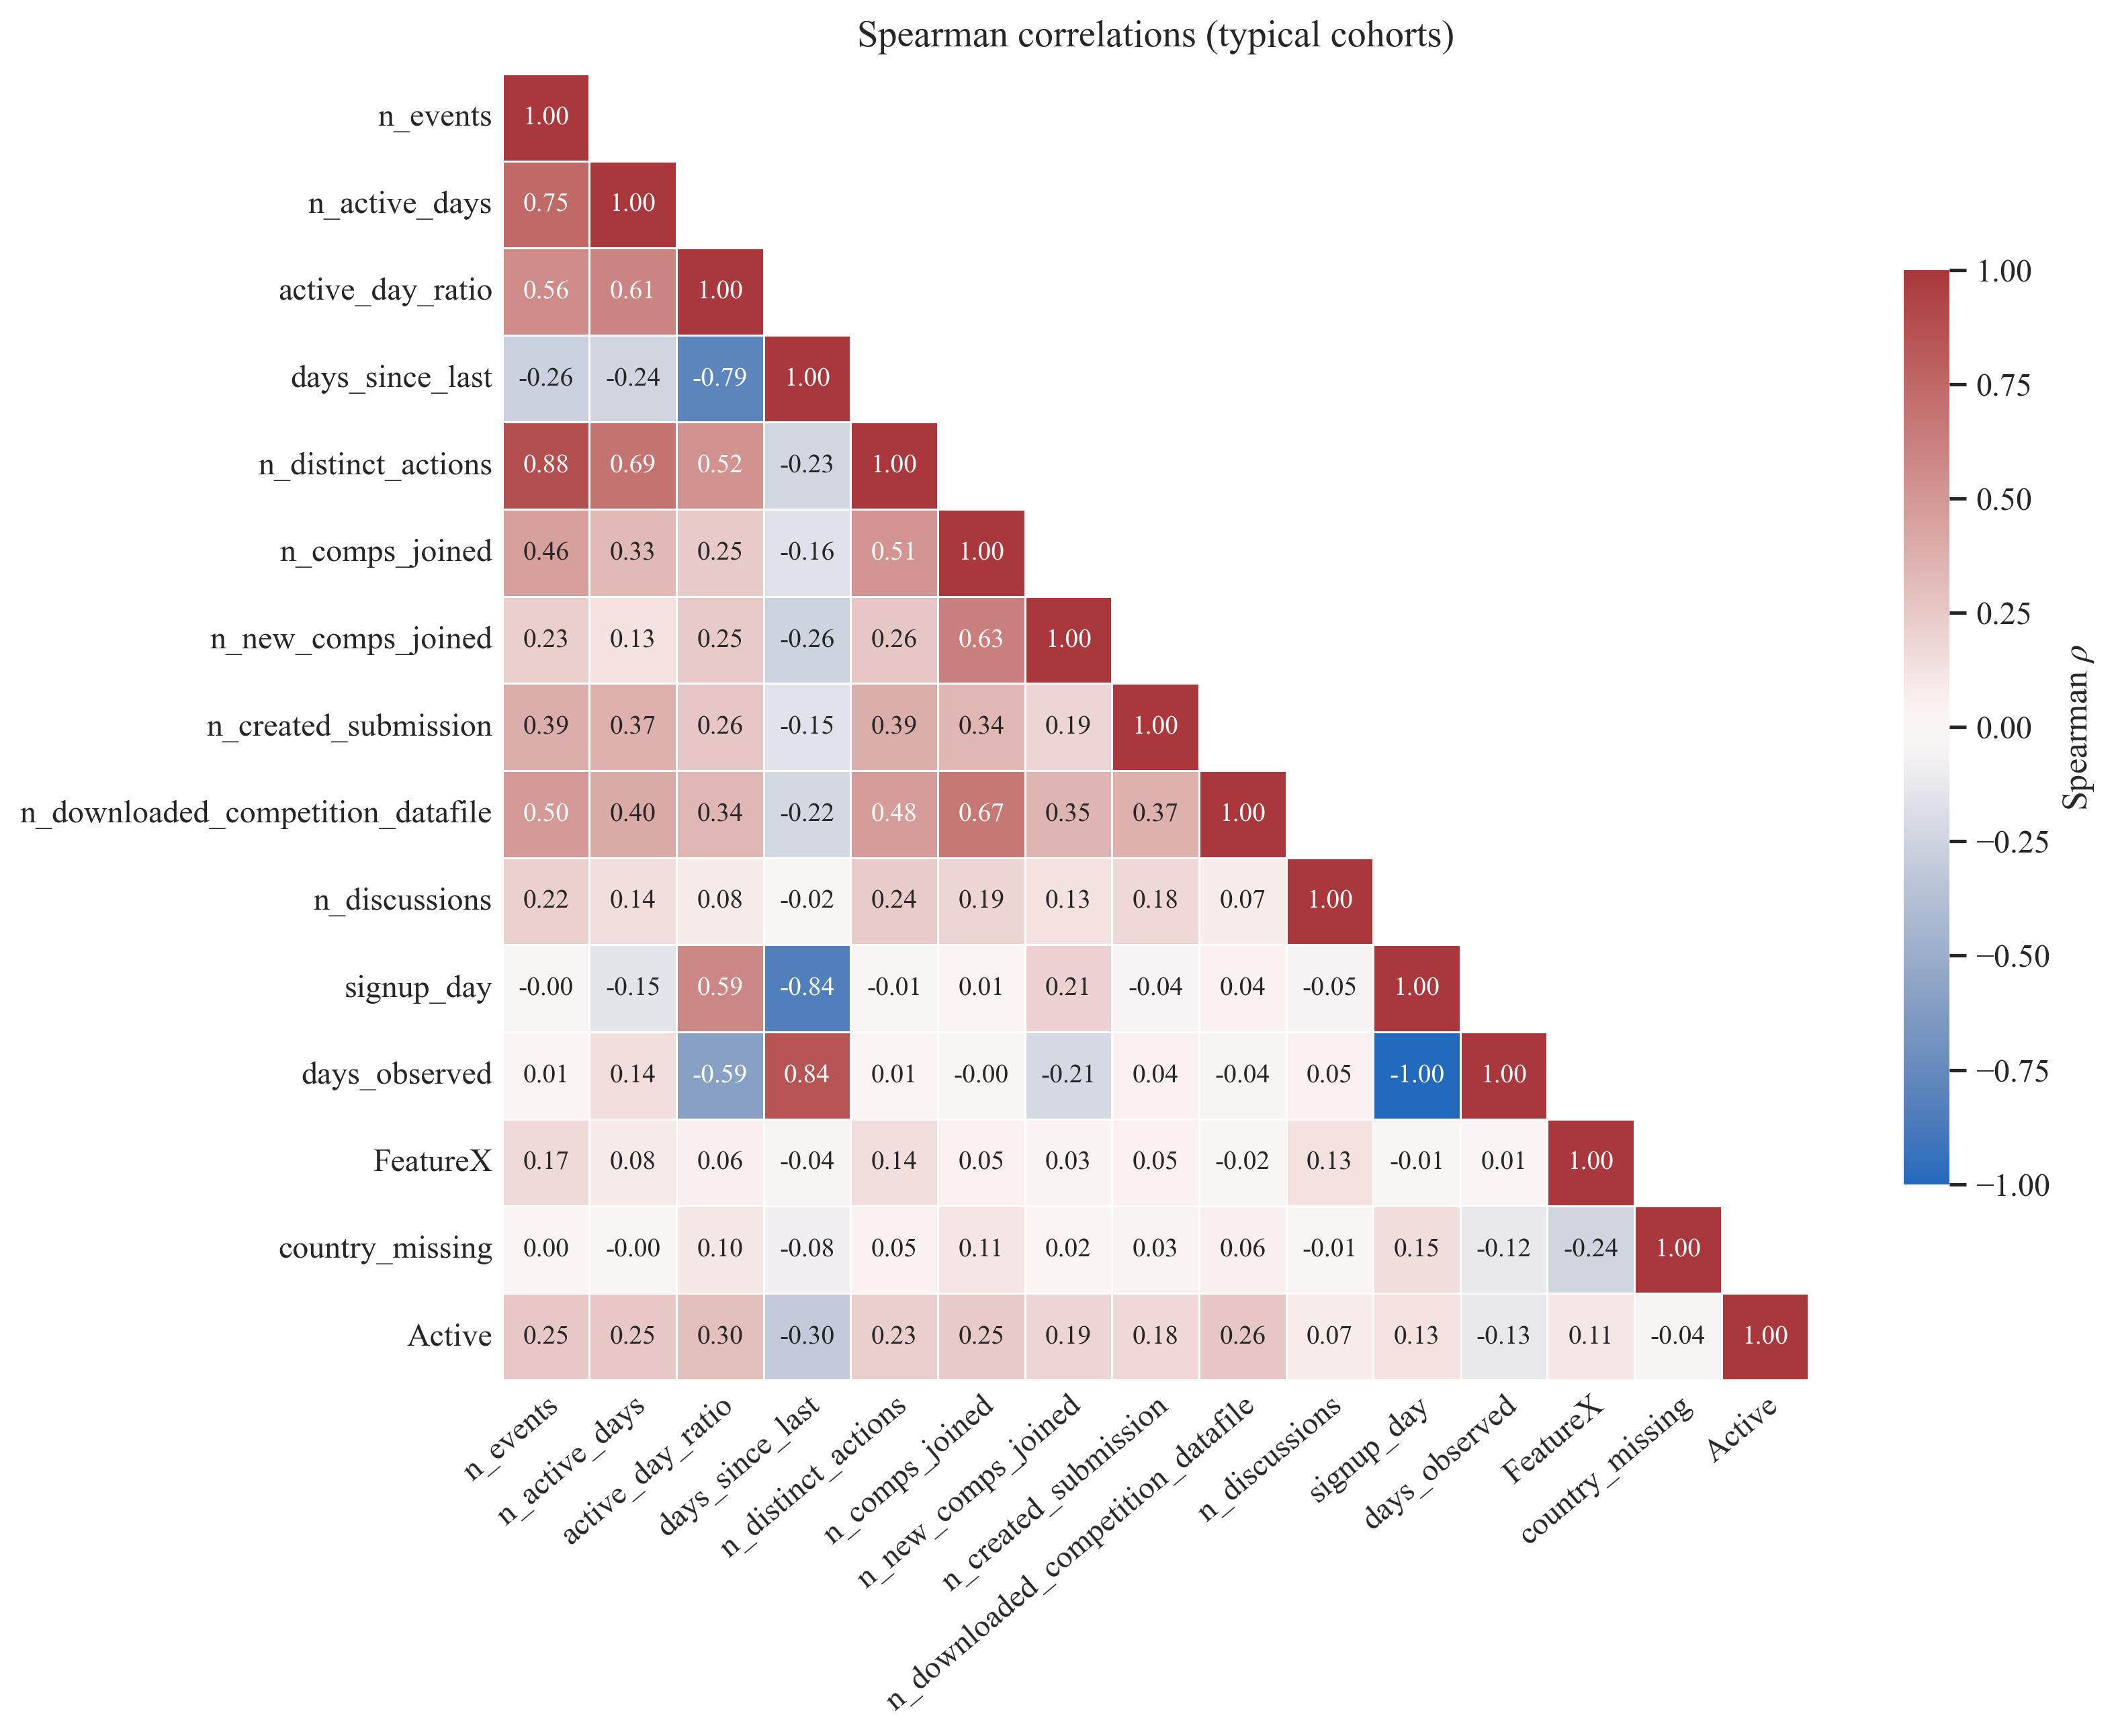

In [13]:
corr_feats = ['n_events', 'n_active_days', 'active_day_ratio', 'days_since_last', 'n_distinct_actions', 'n_comps_joined',
              'n_new_comps_joined', 'n_created_submission', 'n_downloaded_competition_datafile', 'n_discussions',
              'signup_day', 'days_observed', 'FeatureX', 'country_missing', 'Active']
c = normal[corr_feats].corr(method='spearman')
fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(c, mask=np.triu(np.ones_like(c, dtype=bool), 1), cmap='vlag', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 9.5}, linewidths=0.6, linecolor='white', square=True,
            cbar_kws={'shrink': 0.7, 'label': r'Spearman $\rho$'}, ax=ax)
ax.set_title('Spearman correlations (typical cohorts)'); ax.grid(False)
ax.tick_params(axis='both', length=0); ax.tick_params(axis='x', rotation=40)
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')
plt.show()

- Activity features are strongly **collinear** ($\rho$ 0.6–0.9) → L2-regularised logistic regression; trees handle it natively.
- The strongest single correlates of `Active` are regularity (`n_active_days`) and recency (`days_since_last`, negative).
- `signup_day` and `days_observed` are mirror images ($\rho$ = −1). Interestingly late sign-ups are *more* likely to be active next month ($\rho$ = +0.13): their first sessions spill over into month 2. The model must see sign-up timing to interpret activity counts correctly.

## 4. Validation design and metric

**Cross-validation — forward chaining by cohort** (train on past cohorts, validate on the next one), because
at deployment time the model is trained on past cohorts and applied to a new one; random K-fold would leak cohort-level information.

| split | train cohorts | validate on |
|---|---|---|
| inner fold 1 | M11 (+M12) | M1 |
| inner fold 2 | M11 (+M12), M1 | M2 |
| **hold-out test** | M11 (+M12), M1, M2 | **M3** (never used for tuning) |

Hyper-parameters **and the final model family** are selected on the two inner folds only; the decision threshold is chosen on the inner out-of-fold predictions;
the M3 cohort is scored **once** at the end.

**Metric — F1 of the positive class** (the competition metric): positives are only 12–21 %, so accuracy is useless
(predict "all inactive" → 85 % accuracy, F1 = 0). F1 balances *precision* (don't waste retention budget) and *recall*
(don't miss engaged users). For model selection we use **PR-AUC (average precision)**, which is threshold-free and focuses on the minority class.

In [14]:
coh = lab.cohort.values

def forward_folds(cohorts, val_cohorts=(2, 3), exclude=()):
    # expanding-window folds: train on all earlier cohorts, validate on one cohort
    return [(np.where((cohorts < v) & ~np.isin(cohorts, exclude))[0], np.where(cohorts == v)[0]) for v in val_cohorts]

dev = coh <= 3                              # development cohorts (M11, M12, M1, M2)
hold = coh == 4                             # hold-out cohort (M3)
X_dev, y_dev, coh_dev = X[dev], y[dev], coh[dev]
X_hold, y_hold = X[hold], y[hold]
print('dev:', X_dev.shape, ' hold-out (M3):', X_hold.shape, f' hold-out positive rate {y_hold.mean():.3f}')

dev: (7026, 50)  hold-out (M3): (2000, 50)  hold-out positive rate 0.121


### Why not random K-fold? — a quick demonstration

In [15]:
demo = HistGradientBoostingClassifier(random_state=RNG)
p_rand = cross_val_predict(demo, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=RNG), method='predict_proba')[:, 1]
rows = [('random 5-fold (all cohorts mixed)', average_precision_score(y, p_rand))]
for tr, va in forward_folds(coh, val_cohorts=(2, 3, 4)):
    p = clone(demo).fit(X.iloc[tr], y.iloc[tr]).predict_proba(X.iloc[va])[:, 1]
    rows.append((f'forward: train < {LABEL[coh[va][0]]} → validate {LABEL[coh[va][0]]}', average_precision_score(y.iloc[va], p)))
pd.DataFrame(rows, columns=['scheme', 'PR-AUC']).round(3)

,scheme,PR-AUC
0,random 5-fold (all cohorts mixed),0.849
1,forward: train < M1 → validate M1,0.296
2,forward: train < M2 → validate M2,0.469
3,forward: train < M3 → validate M3,0.464


Random K-fold reports PR-AUC $\approx$ 0.85; honest forward validation gives $\approx$ 0.3–0.5. Part of the gap is the higher base rate
when M12 is mixed in, but mostly the model **memorises cohort-specific signals** (e.g. which hackathon, whether country is recorded)
that do not transfer to a future cohort. Every number from here on uses forward validation.

## 5. Models and hyper-parameter search

| model | why |
|---|---|
| **Heuristic baseline** — "active on $\geq$ *k* days" | what a product manager would do without ML |
| **Logistic regression** (log1p + scaling, L2, class-balanced) | interpretable, robust to shift, handles collinearity via regularisation |
| **Random forest** (class-balanced) | non-linear, robust, few assumptions |
| **Histogram gradient boosting** | state of the art for tabular data, native handling of skewed counts & interactions |

Grid search (`GridSearchCV` with our forward folds, scoring = PR-AUC), then two data-level choices suggested by the EDA:
**(a)** keep or drop the anomalous M12 cohort from training, **(b)** keep or drop country features.

In [16]:
log_lr = make_pipeline(FunctionTransformer(np.log1p), StandardScaler(),
                       LogisticRegression(max_iter=5000, class_weight='balanced'))
SEARCH = {
    'LogReg': (log_lr, {'logisticregression__C': [0.003, 0.01, 0.03, 0.1, 0.3, 1]}),
    'RandomForest': (RandomForestClassifier(n_estimators=400, class_weight='balanced_subsample', n_jobs=-1, random_state=RNG),
                     {'max_depth': [6, 10, None], 'min_samples_leaf': [5, 20, 50], 'max_features': ['sqrt', 0.4]}),
    'GradBoost': (HistGradientBoostingClassifier(random_state=RNG),
                  {'learning_rate': [0.03, 0.1], 'max_iter': [100, 300], 'max_leaf_nodes': [7, 15, 31],
                   'min_samples_leaf': [20, 80], 'l2_regularization': [0.0, 1.0]}),
}
NO_COUNTRY = [f for f in FEATURES if not f.startswith('cty_') and f != 'country_missing']

def search(name, drop_m12, feats):
    est, grid = SEARCH[name]
    folds = forward_folds(coh_dev, exclude=(1,) if drop_m12 else ())
    gs = GridSearchCV(est, grid, scoring='average_precision', cv=folds, n_jobs=-1, refit=False)
    gs.fit(X_dev[feats], y_dev)
    return gs.best_params_, gs.best_score_

results = []
for name in SEARCH:
    for drop_m12 in (False, True):
        for feat_set, feats in (('all', FEATURES), ('no country', NO_COUNTRY)):
            params, score = search(name, drop_m12, feats)
            results.append(dict(model=name, train_M12='dropped' if drop_m12 else 'kept', features=feat_set,
                                cv_PR_AUC=score, params=params))
res = pd.DataFrame(results)
res.pivot_table(index='model', columns=['train_M12', 'features'], values='cv_PR_AUC').round(3)

train_M12    dropped              kept           
features         all no country    all no country
model                                            
GradBoost      0.499      0.508  0.425      0.425
LogReg         0.471      0.474  0.436      0.450
RandomForest   0.500      0.497  0.446      0.470

- **Dropping the M12 cohort from training helps every model** — the event-driven cohort teaches the wrong base rate and wrong patterns.
- Country features: small / inconsistent effect → we keep the simpler, more shift-robust variant when scores tie (see below).
- Selected configuration per model (best CV PR-AUC):

In [17]:
best = res.sort_values('cv_PR_AUC', ascending=False).groupby('model').head(1).set_index('model')
for name, p in best.params.items():
    print(f'{name:>12}: ' + ', '.join(f"{k.split('__')[-1]}={v}" for k, v in p.items()))
best[['train_M12', 'features', 'cv_PR_AUC']].round(3)

   GradBoost: l2_regularization=1.0, learning_rate=0.03, max_iter=100, max_leaf_nodes=7, min_samples_leaf=80
RandomForest: max_depth=6, max_features=0.4, min_samples_leaf=50
      LogReg: C=0.003


,train_M12,features,cv_PR_AUC
model,,,
GradBoost,dropped,no country,0.508
RandomForest,dropped,all,0.500
LogReg,dropped,no country,0.474


## 5.1 Threshold selection and final evaluation on the hold-out cohort (M3)

For each tuned model: out-of-fold probabilities on the inner folds → pick the threshold maximising F1 →
refit on all development cohorts → score M3 once.

In [18]:
def f1_threshold(y_true, p):
    grid = np.arange(0.05, 0.96, 0.01)
    return grid[np.argmax([f1_score(y_true, p >= t) for t in grid])]

def build(name, params):
    return clone(SEARCH[name][0]).set_params(**params)

final, probs = [], {}
for name, row in best.iterrows():
    feats = FEATURES if row.features == 'all' else NO_COUNTRY
    excl = (1,) if row.train_M12 == 'dropped' else ()
    oof_y, oof_p = [], []
    for tr, va in forward_folds(coh_dev, exclude=excl):
        m = build(name, row.params).fit(X_dev.iloc[tr][feats], y_dev.iloc[tr])
        oof_y.append(y_dev.iloc[va]); oof_p.append(m.predict_proba(X_dev.iloc[va][feats])[:, 1])
    thr = f1_threshold(np.concatenate(oof_y), np.concatenate(oof_p))
    keep = ~np.isin(coh_dev, excl)
    model = build(name, row.params).fit(X_dev[keep][feats], y_dev[keep])
    p = model.predict_proba(X_hold[feats])[:, 1]; probs[name] = p
    final.append(dict(model=name, threshold=thr, F1=f1_score(y_hold, p >= thr), precision=precision_score(y_hold, p >= thr),
                      recall=recall_score(y_hold, p >= thr), PR_AUC=average_precision_score(y_hold, p), ROC_AUC=roc_auc_score(y_hold, p)))
    best.loc[name, 'threshold'] = thr

# heuristic baseline: active on >= k days, k tuned on the same inner folds
oof = np.concatenate([va for _, va in forward_folds(coh_dev, exclude=(1,))])
k = max(range(1, 10), key=lambda k: f1_score(y_dev.iloc[oof], X_dev.n_active_days.iloc[oof] >= k))
pb = (X_hold.n_active_days >= k).astype(int)
final.append(dict(model=f'Baseline (active days >= {k})', threshold=np.nan, F1=f1_score(y_hold, pb), precision=precision_score(y_hold, pb),
                  recall=recall_score(y_hold, pb), PR_AUC=np.nan, ROC_AUC=np.nan))
final.append(dict(model='Predict everyone active', threshold=np.nan, F1=f1_score(y_hold, np.ones_like(y_hold)),
                  precision=y_hold.mean(), recall=1.0, PR_AUC=y_hold.mean(), ROC_AUC=0.5))
final = pd.DataFrame(final).set_index('model')
final.round(3)

,threshold,F1,precision,recall,PR_AUC,ROC_AUC
model,,,,,,
GradBoost,0.32,0.472,0.451,0.494,0.479,0.830
RandomForest,0.60,0.462,0.412,0.527,0.451,0.817
LogReg,0.61,0.484,0.433,0.547,0.482,0.820
Baseline (active days >= 2),NaN,0.359,0.259,0.588,NaN,NaN
Predict everyone active,NaN,0.217,0.122,1.000,0.122,0.500


- **Final model = GradBoost** (highest CV PR-AUC 0.508, trained without M12, without country features). On the hold-out
  cohort it reaches **F1 = 0.47** (precision 0.45, recall 0.49, ROC-AUC 0.83).
- All three ML models are within ~0.02 F1 of each other on M3 (LogReg is marginally higher, 0.48) — differences of that size
  are within the noise of a 243-positive test cohort, so we keep the CV-selected model rather than cherry-picking on the hold-out.
- Every ML model beats the product rule-of-thumb (**+0.11 F1**) and the trivial "everyone active" rule (**+0.25 F1**).

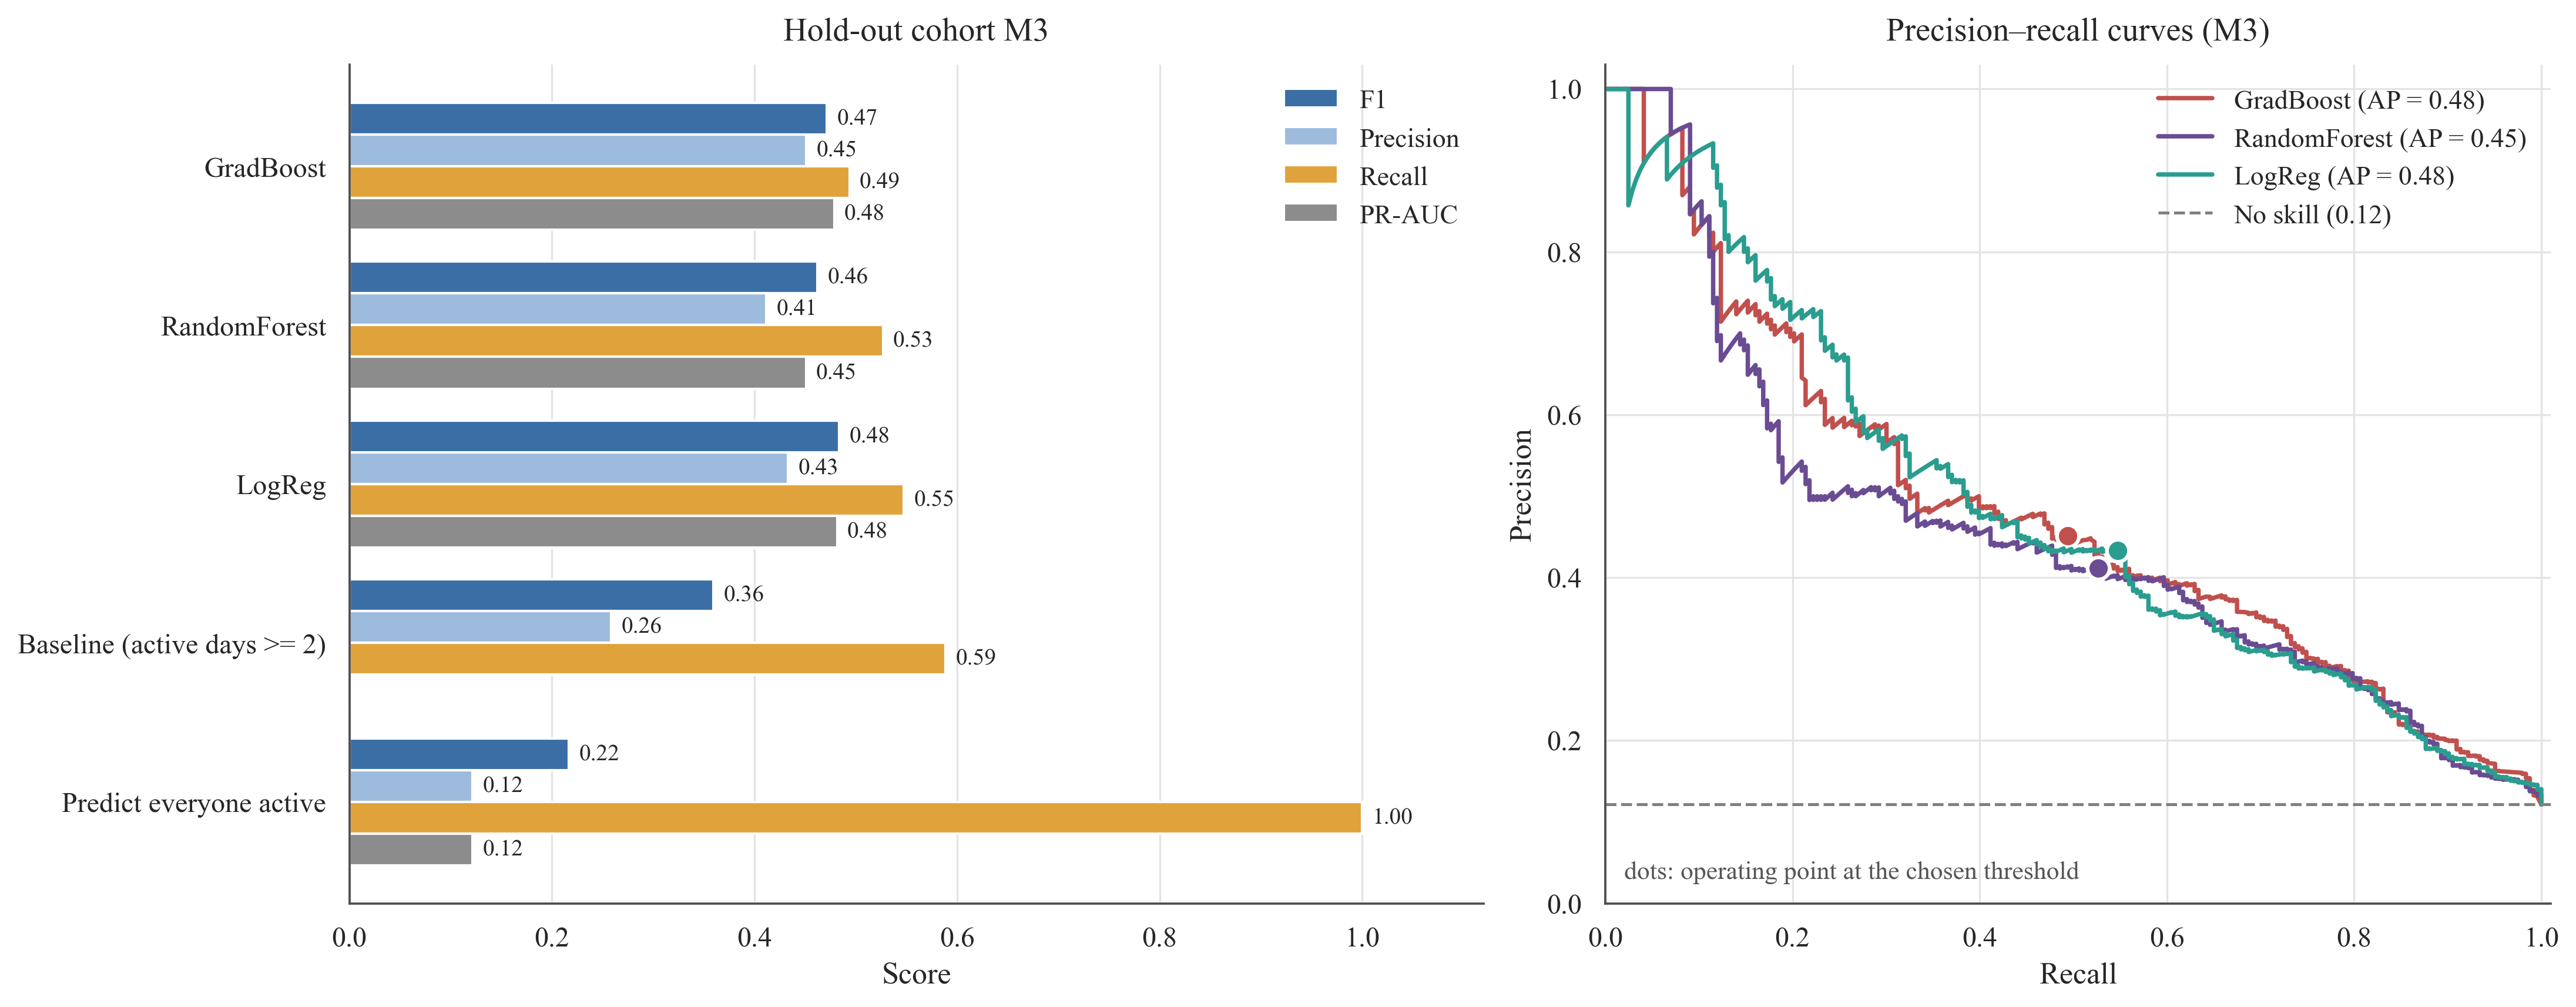

In [19]:
METRICS = {'F1': '#3A6EA5', 'precision': '#9DBBDD', 'recall': '#E0A33B', 'PR_AUC': '#8C8C8C'}
MODEL_COLORS = {'GradBoost': '#C0504D', 'RandomForest': '#6A4C93', 'LogReg': '#2A9D8F'}

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.6), gridspec_kw={'width_ratios': [1.2, 1]})
ax = axes[0]; models = final.index.tolist(); yy = np.arange(len(models)); h = 0.2
for i, (m, col) in enumerate(METRICS.items()):
    vals = final[m].values.astype(float); ypos = yy + (i - 1.5) * h
    ax.barh(ypos, np.nan_to_num(vals), height=h, color=col, label=m.replace('_', '-').replace('precision', 'Precision').replace('recall', 'Recall'))
    for yp, v in zip(ypos, vals):
        if not np.isnan(v):
            ax.text(v + 0.01, yp, f'{v:.2f}', va='center', fontsize=9.5)
ax.set_yticks(yy, models); ax.invert_yaxis(); ax.set_xlim(0, 1.12); ax.grid(axis='y', visible=False)
ax.set(title='Hold-out cohort M3', xlabel='Score'); ax.legend(loc='upper right')

ax = axes[1]
for name, p in probs.items():
    col = MODEL_COLORS.get(name, BLUE)
    pr, rc, _ = precision_recall_curve(y_hold, p)
    ax.plot(rc, pr, color=col, lw=1.8, label=f'{name} (AP = {average_precision_score(y_hold, p):.2f})')
    ax.plot(final.loc[name, 'recall'], final.loc[name, 'precision'], 'o', color=col, ms=9, mec='white', mew=1.5)
ax.axhline(y_hold.mean(), ls='--', c='grey', lw=1.2, label=f'No skill ({y_hold.mean():.2f})')
ax.text(0.02, 0.03, 'dots: operating point at the chosen threshold', transform=ax.transAxes, fontsize=10.5, color='#555555')
ax.set(xlabel='Recall', ylabel='Precision', title='Precision–recall curves (M3)', xlim=(0, 1.01), ylim=(0, 1.03))
ax.legend(loc='upper right')
plt.show()

## 5.2 What drives the best model?

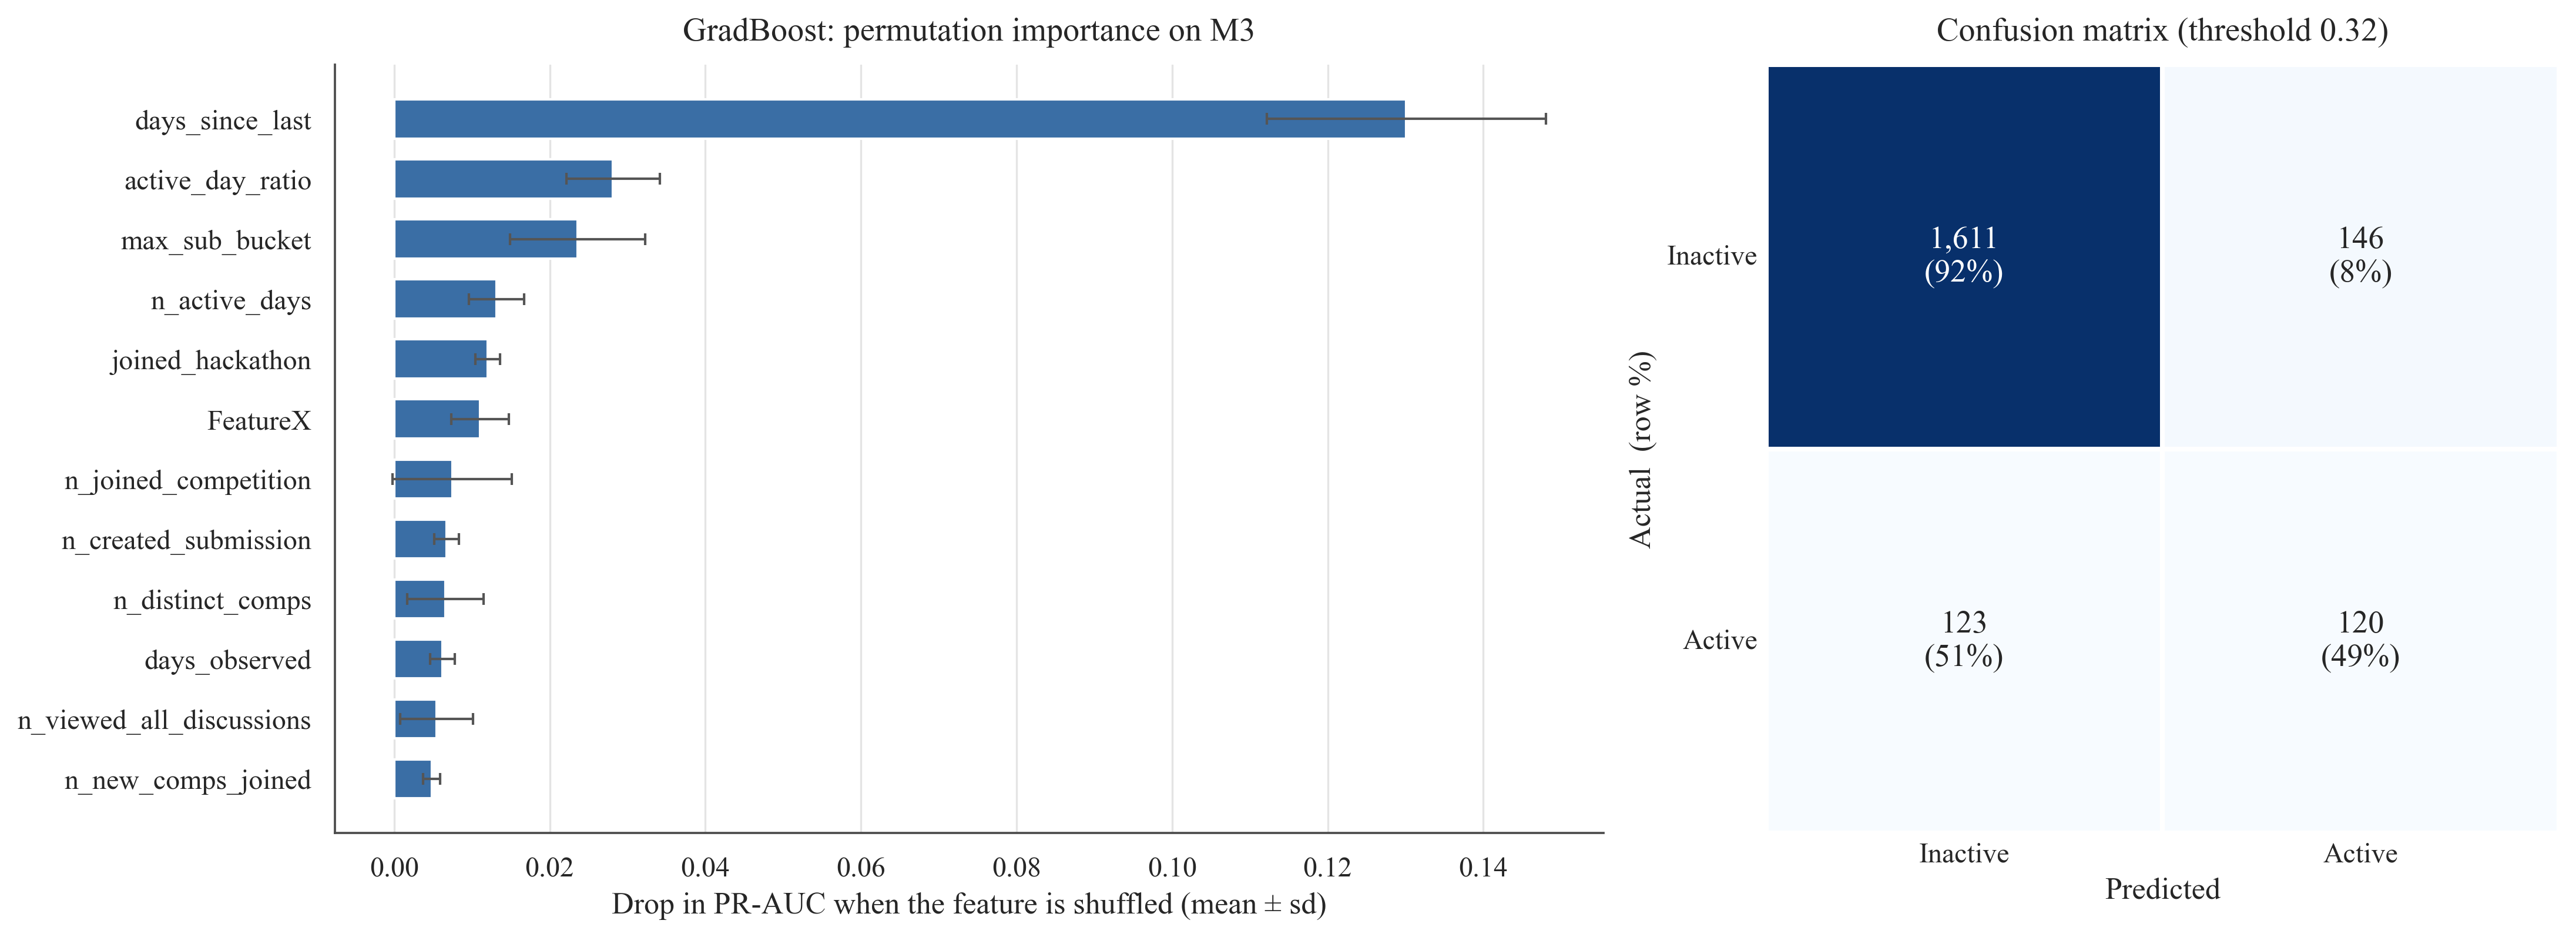

In [20]:
BEST = best.cv_PR_AUC.idxmax()          # chosen on CV only — the hold-out is never used for selection
row = best.loc[BEST]; feats = FEATURES if row.features == 'all' else NO_COUNTRY
excl = (1,) if row.train_M12 == 'dropped' else ()
best_model = build(BEST, row.params).fit(X_dev[~np.isin(coh_dev, excl)][feats], y_dev[~np.isin(coh_dev, excl)])
pi = permutation_importance(best_model, X_hold[feats], y_hold, scoring='average_precision', n_repeats=10, random_state=RNG, n_jobs=-1)
imp = pd.Series(pi.importances_mean, feats).sort_values(ascending=False).head(12)

p_best = probs[BEST]; thr = best.loc[BEST, 'threshold']
imp_sd = pd.Series(pi.importances_std, feats)[imp.index]
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2), gridspec_kw={'width_ratios': [1.6, 1]})
ax = axes[0]
ax.barh(imp.index[::-1], imp.values[::-1], xerr=imp_sd.values[::-1], color=BLUE, height=0.65,
        error_kw={'lw': 1, 'ecolor': '#555555', 'capsize': 2.5})
ax.grid(axis='y', visible=False)
ax.set(title=f'{BEST}: permutation importance on M3', xlabel='Drop in PR-AUC when the feature is shuffled (mean ± sd)')
cm = confusion_matrix(y_hold, p_best >= thr)
ann = np.array([[f'{v:,}\n({v / cm[i].sum():.0%})' for v in cm[i]] for i in range(2)])
sns.heatmap(cm, annot=ann, fmt='', cmap='Blues', cbar=False, ax=axes[1], linewidths=1.5, linecolor='white',
            annot_kws={'size': 13}, xticklabels=['Inactive', 'Active'], yticklabels=['Inactive', 'Active'])
axes[1].set(title=f'Confusion matrix (threshold {thr:.2f})', xlabel='Predicted', ylabel='Actual  (row %)')
axes[1].tick_params(axis='both', length=0); axes[1].tick_params(axis='y', rotation=0); axes[1].grid(False)
plt.show()

- **Recency** (`days_since_last`) is by far the most important signal, followed by **regularity** (`active_day_ratio`,
  `n_active_days`) and *doing* signals (successful-submission bucket, competitions joined, submissions, hackathon participation).
- Profile variables contribute little (only the masked `FeatureX` appears in the top 12; country was dropped by the search) —
  engagement is about **behaviour, not demographics**, which is good for fairness and actionability.
- At the F1-optimal threshold the model finds about half of the returning users with ~45 % precision ($\approx$ 3.7× the 12 % base rate).

## 6. Real-world impact — who should Zindi target?

A retention campaign has a budget: contact the top-*x* % of users ranked by the model.

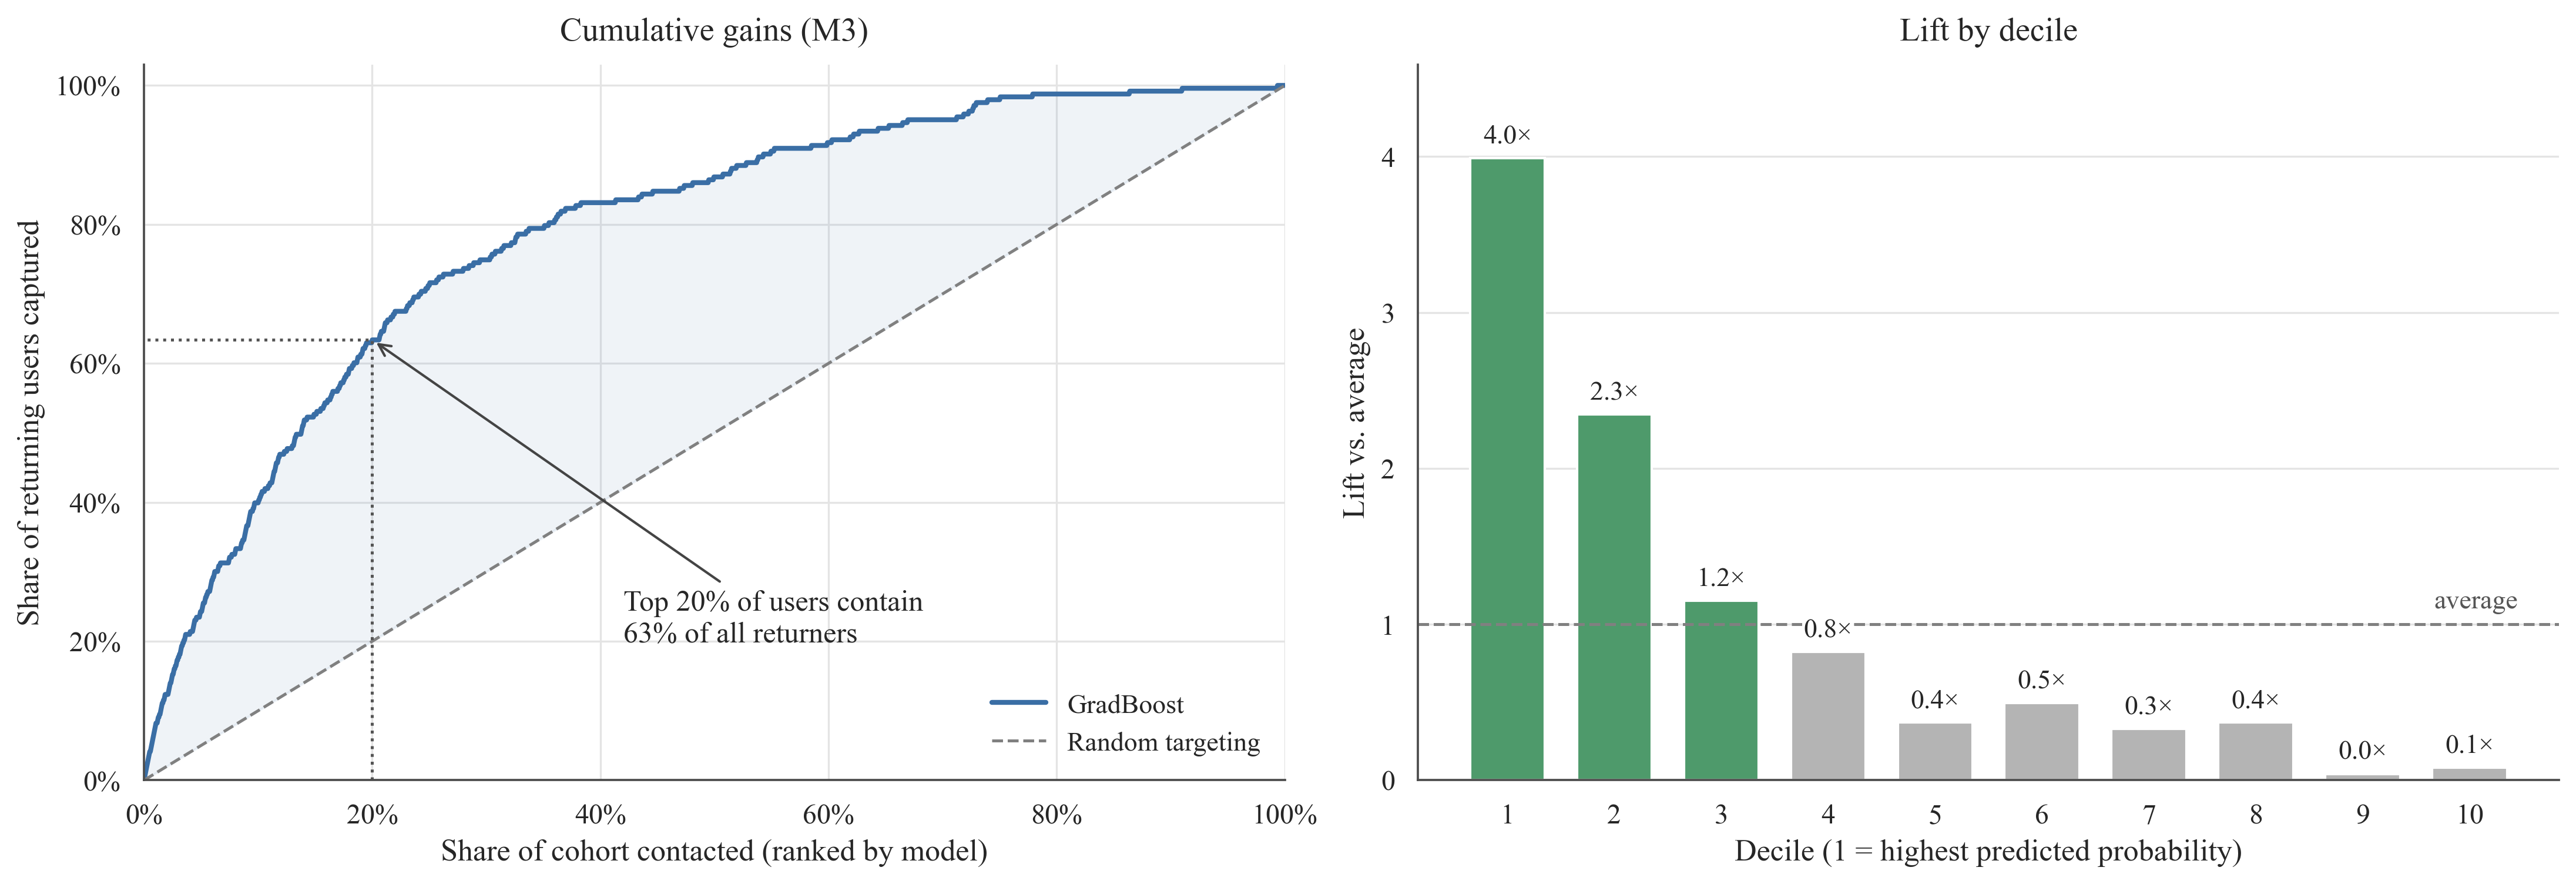

Top 20 % by score contain 63% of all returning users;  bottom 50 % contain only 13%.


In [21]:
order = np.argsort(-p_best)
cum_pos = np.cumsum(y_hold.values[order]) / y_hold.sum()
share = np.arange(1, len(order) + 1) / len(order)
top20 = cum_pos[int(.2 * len(order)) - 1]
bottom50 = 1 - cum_pos[int(.5 * len(order)) - 1]
dec = pd.qcut(pd.Series(p_best).rank(method='first'), 10, labels=range(10, 0, -1))
lift = pd.Series(y_hold.values).groupby(dec).mean() / y_hold.mean()
lift.index = lift.index.astype(int); lift = lift.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.9))
ax = axes[0]
ax.plot(share, cum_pos, color=BLUE, lw=2, label=BEST)
ax.plot([0, 1], [0, 1], '--', c='grey', lw=1.2, label='Random targeting')
ax.fill_between(share, share, cum_pos, color=BLUE, alpha=0.08)
ax.plot([0.2, 0.2, 0], [0, top20, top20], ':', color='#555555', lw=1.2)
ax.annotate(f'Top 20% of users contain\n{top20:.0%} of all returners', xy=(0.2, top20), xytext=(0.42, 0.2),
            arrowprops={'arrowstyle': '->', 'color': '#444444', 'lw': 1}, fontsize=12)
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set(xlabel='Share of cohort contacted (ranked by model)', ylabel='Share of returning users captured',
       title='Cumulative gains (M3)', xlim=(0, 1), ylim=(0, 1.03))
ax.legend(loc='lower right')

ax = axes[1]
ax.bar(lift.index, lift.values, color=[GREEN if v >= 1 else GREY for v in lift.values], width=0.7)
for x, v in zip(lift.index, lift.values):
    ax.text(x, v + 0.06, f'{v:.1f}×', ha='center', va='bottom', fontsize=11, zorder=3,
            bbox={'facecolor': 'white', 'edgecolor': 'none', 'pad': 0.6})
ax.axhline(1, ls='--', c='grey', lw=1.2); ax.text(10.45, 1.07, 'average', ha='right', va='bottom', fontsize=11, color='#555555')
ax.set_xticks(range(1, 11)); ax.set_ylim(0, lift.max() * 1.15); ax.grid(axis='x', visible=False)
ax.set(xlabel='Decile (1 = highest predicted probability)', ylabel='Lift vs. average', title='Lift by decile')
plt.show()
print(f'Top 20 % by score contain {top20:.0%} of all returning users;  bottom 50 % contain only {bottom50:.0%}.')

**Reading the curves**: the top decile is **4×** more likely to return than average; the top 20 % of users by score contain
**63 %** of all returners, while the bottom half contains only **13 %**.

**Illustrative business case** (assumptions stated explicitly — to be replaced by Zindi's real numbers):

- *Churn-prevention campaign*: the model's **bottom half** holds very few returners, so Zindi can
  concentrate a costly personal intervention (mentor call, tailored beginner competition) on the **middle deciles** —
  users with some engagement but uncertain outcome — instead of the whole cohort.
- *Community / recruiting*: the **top decile** is several times more likely to be active than average → the natural
  shortlist for hackathon invitations and ambassador programmes.
- Example: 2 000 sign-ups/month, intervention cost 5 USD/user. Contacting everybody = 10 000 USD. Contacting the 40 % "uncertain"
  segment = 4 000 USD (−60 %) while still covering the users whose behaviour can plausibly be changed.
- The *causal* effect of an intervention cannot be estimated from these observational data → an **A/B test**
  (random hold-out within the targeted segment) is required before claiming revenue impact.

## 6.1 Predictions for the official test cohort (M4)

In [22]:
keep = ~np.isin(coh, excl)                             # final model: all labelled cohorts except excluded ones
final_model = build(BEST, row.params).fit(X[keep][feats], y[keep])
p_test = final_model.predict_proba(X_test[feats])[:, 1]
sub = pd.DataFrame({'User_ID_Next_month_Activity': X_test.index + '_Month_5', 'Active': (p_test >= thr).astype(int)})
sub = sample_sub[['User_ID_Next_month_Activity']].merge(sub, how='left').fillna({'Active': 0}).astype({'Active': int})
sub.to_csv('submission.csv', index=False)
print(f'{len(sub)} rows written to submission.csv; predicted active share = {sub.Active.mean():.3f}')
print(f'(M4 activity log ends on day {act[act.t == TEST_COHORT].day.max()} — late sign-ups have truncated features)')
sub.head()

1340 rows written to submission.csv; predicted active share = 0.109
(M4 activity log ends on day 22 — late sign-ups have truncated features)


,User_ID_Next_month_Activity,Active
0,ID_4TOXNBGB_Month_5,0
1,ID_CHFTIP26_Month_5,0
2,ID_FU5GMWLQ_Month_5,0
3,ID_254TVBQP_Month_5,0
4,ID_4ENO2VFE_Month_5,0


## 7. Conclusions

**Findings**

- The labelled training set had to be *reconstructed*: we de-anonymised the month order from the data itself and derived the target.
- **Recency and regularity of first-month activity** predict month-2 retention far better than demographics; *doing* (submitting, downloading data, joining) beats *browsing*.
- Retention is **non-stationary**: one hackathon made a cohort's retention jump from ~15 % to 78 %; the sign-up form change
  made `country` missing for most later users. Both would silently break a naïvely validated model.

**ML experiment critique**

- Random K-fold would have overstated performance by ~2×; forward-chaining CV is the honest estimate.
- Excluding the event-driven cohort from training was the single most useful "data" decision; model choice mattered less than validation design.
- Limits: only 5 labelled cohorts (small, noisy fold estimates); masked features; M4 log truncated at day 22;
  retention of event cohorts is driven by an *external calendar* (hackathons) that the features only partially capture.

**Did we solve the problem?** Largely for *ranking*, partly for *exact classification*. On an unseen future cohort the
model reaches F1 = 0.47 vs 0.36 for the best rule of thumb, and concentrates 63 % of returners in the top 20 % of users — enough to
make targeted retention/community programmes several times cheaper than blanket campaigns. Absolute F1 stays moderate
because many returns are triggered by future events (new competitions, hackathons) that are invisible in month 1.

**Next steps**: add the platform's competition calendar (upcoming launches) as features; train on more cohorts;
calibrate probabilities per cohort; validate business impact with an A/B-tested retention campaign.